In [1]:
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
from typing import Union, Tuple
from tkinter.constants import E
import numpy as np
# project_root = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
# quarot_path = os.path.join(project_root, 'quarot')
# sys.path.insert(0, project_root)  
# sys.path.insert(0, quarot_path)   
from train.segment_anything_training.modeling.image_encoder import ImageEncoderViT as ImageEncoderViTtrain
from train.segment_anything_training.modeling.image_encoder import (
    Block, 
    Attention,
    window_unpartition, 
    window_partition
) 
from segment_anything import build_sam, sam_model_registry, SamPredictor
from segment_anything.modeling.image_encoder import ImageEncoderViT  
from segment_anything.modeling.mask_decoder_hq import MaskDecoderHQ
from segment_anything.modeling.mask_decoder import MaskDecoder
from typing import Optional, Callable
from functools import partial


/u/ctran3/Sam_quantization/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/u/ctran3/Sam_quantization/.venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/u/ctran3/Sam_quantization/.venv/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/u/ctran3/Sam_quantization/sam-hq/segment_anything/modeling/tiny_vit_sam.py:662: UserWarning: Overwriting tiny_vit_5m_224 in registry with segmen

In [2]:
def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    
def show_mask_image(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2)
    ax.imshow(mask_image)


class ObserverBase:
    dictionary = {}
    def __init__(self, module_list: Tuple):
        self.module_list = module_list
        self.hooks = []

    def register_hooks(self,
        model: nn.Module,
        pre_hook: Optional[Callable] = None,
        post_hook: Optional[Callable] = None,
    ):
        for name, module in model.named_modules():
            if post_hook is not None:
                if isinstance(module, self.module_list):
                    self.hooks.append(
                        module.register_forward_hook(partial(post_hook, name=name))
                    )
            if pre_hook is not None:
                if isinstance(module, self.module_list):
                    self.hooks.append(
                        module.register_forward_pre_hook(partial(pre_hook, name=name))
                    )

    def clear_hook(self):
        for hook in self.hooks:
            hook.remove()

    def clear_dict(self):
        ObserverBase.dictionary = {}

    @torch.inference_mode()
    def inference_image(
        self,
        predictor,
        image_dir: str = './input_imgs/example1.png',
        show_image: bool = False,
        example_idx: int = 1,  # Which example configuration to use
    ):
        """
        Run inference on a single image using either SamPredictor or Sam model directly
        """
        import cv2
        image = cv2.imread(image_dir)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Configure based on example index
        if example_idx == 0:
            input_box = np.array([[4, 13, 1007, 1023]])
            input_point, input_label = None, None
            hq_token_only = False
        elif example_idx == 1:
            input_box = np.array([[306, 132, 925, 893]])
            input_point, input_label = None, None
            hq_token_only = True
        elif example_idx == 2:
            input_point = np.array([[495, 518], [217, 140]])
            input_label = np.ones(input_point.shape[0])
            input_box = None
            hq_token_only = True
        elif example_idx == 3:
            input_point = np.array([[221, 482], [498, 633], [750, 379]])
            input_label = np.ones(input_point.shape[0])
            input_box = None
            hq_token_only = False
        elif example_idx == 4:
            input_box = np.array([[64, 76, 940, 919]])
            input_point, input_label = None, None
            hq_token_only = True
        else:
            # Default fallback
            input_box = np.array([[306, 132, 925, 893]])
            input_point, input_label = None, None
            hq_token_only = True
        
        # Check if predictor is SamPredictor or Sam model
        if isinstance(predictor, SamPredictor):
            # Use existing SamPredictor logic
            predictor.set_image(image)
            
            try:
                # Try to predict with hq_token_only parameter
                masks, scores, logits = predictor.predict(
                    point_coords=input_point,
                    point_labels=input_label,
                    box=input_box,
                    multimask_output=False,
                    hq_token_only=hq_token_only,
                )
            except TypeError as e:
                if "hq_token_only" in str(e):
                    # Fall back to standard prediction without hq_token_only
                    print("Warning: hq_token_only parameter not supported, using standard prediction")
                    masks, scores, logits = predictor.predict(
                        point_coords=input_point,
                        point_labels=input_label,
                        box=input_box,
                        multimask_output=False,
                    )
                else:
                    raise e
                    
        else: #Sam is not None and isinstance(predictor, Sam):
            # Use direct Sam model inference
            masks, scores, logits = self._inference_with_sam_model(
                sam_model=predictor,
                image=image,
                input_point=input_point,
                input_label=input_label,
                input_box=input_box,
                hq_token_only=hq_token_only
            )
        # else:
        #     raise ValueError(f"Unsupported predictor type: {type(predictor)}")
        
        if show_image:
            plt.figure(figsize=(10, 10))
            plt.imshow(image)
            
            if len(masks) > 0:
                show_mask_image(masks[0], plt.gca(), random_color=False)
            
            if input_box is not None:
                box = input_box[0]
                x0, y0 = box[0], box[1]
                w, h = box[2] - box[0], box[3] - box[1]
                plt.gca().add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))
            
            if input_point is not None and input_label is not None:
                show_points(input_point, input_label, plt.gca())
                
            plt.title(f'Example {example_idx} - Score: {scores[0]:.3f}')
            plt.axis('off')
            plt.show()

        return masks, scores, logits

    def _inference_with_sam_model(
        self,
        sam_model: 'Sam',
        image: np.ndarray,
        input_point: Optional[np.ndarray] = None,
        input_label: Optional[np.ndarray] = None,
        input_box: Optional[np.ndarray] = None,
        hq_token_only: bool = False
    ):
        """
        Run inference directly with Sam model (not SamPredictor wrapper)
        """
        # Make sure the entire model is on a single device
        device = next(sam_model.parameters()).device
        sam_model = sam_model.to(device)
        
        # Prepare image tensor
        input_image = torch.as_tensor(image).to(device).permute(2, 0, 1).contiguous()
        original_size = image.shape[:2]
        
        # Prepare batched input for Sam model
        batched_input = []
        dict_input = {
            'image': input_image,
            'original_size': original_size
        }
        
        # Add prompts if provided
        if input_point is not None and input_label is not None:
            point_coords = torch.as_tensor(input_point).to(device)
            point_labels = torch.as_tensor(input_label).to(device)
            dict_input['point_coords'] = point_coords
            dict_input['point_labels'] = point_labels
            
        if input_box is not None:
            boxes = torch.as_tensor(input_box).to(device)
            dict_input['boxes'] = boxes
            
        batched_input.append(dict_input)
        
        # Make sure the model is in eval mode
        sam_model.eval()
        
        # Force all model parameters to correct device
        for module in sam_model.modules():
            for param in module.parameters(recurse=False):
                param.data = param.data.to(device)
            for buffer in module.buffers(recurse=False):
                buffer.data = buffer.data.to(device)

        with torch.no_grad():
            outputs = sam_model(batched_input, multimask_output=False)
            if isinstance(outputs, tuple):
                outputs, interm_embeddings = outputs
            else:
                interm_embeddings = None
                
    
        
        # Extract results from outputs
        if len(outputs) > 0:
            output = outputs[0]
            masks = output['masks'].detach().cpu().numpy()
            scores = output['iou_predictions'].detach().cpu().numpy()
            logits = output['low_res_logits'].detach().cpu().numpy()
        else:
            # Fallback if no outputs
            h, w = original_size
            masks = np.zeros((1, h, w), dtype=bool)
            scores = np.array([0.0])
            logits = np.zeros((1, 256, 256))
            
        return masks, scores, logits

In [3]:
def do_pool(x:torch.Tensor, pool:nn.Module, norm:nn.Module = None) :
    if pool is None:
        return x

    # (B, H , W, C) -> (B, C, H, W)
    x = x.permute(0,3,1,2)
    x = pool(x)
    # (B, C , H', W') -> (B, W', H', C)
    x = x.permute(0,2,3,1)
    if norm:
        x = norm(x)
    return x

def to_numpy(x:torch.Tensor):
    return x.detach().cpu().numpy()


def get_histc(x:torch.Tensor, bins=200, min=-3.0, max=3.0):
    x = x.flatten()
    return torch.histc(x, bins=bins, min=min, max=max)


class Distribution():
    def __init__(self, n_channels:int, dist_name:str ,mean:np.ndarray, max:np.ndarray, min:np.ndarray, p75:np.ndarray, p25:np.ndarray, p99:np.ndarray, p1:np.ndarray):
        self.n_channels = n_channels
        self.mean = mean[:n_channels]
        self.max = max[:n_channels]
        self.min = min[:n_channels]
        self.p75 = p75[:n_channels]
        self.p25 = p25[:n_channels]
        self.p99 = p99[:n_channels]
        self.p1 = p1[:n_channels]
        self.dist_name = dist_name


    def plot_channel_distribution(self, ax ):
        x = np.arange(self.n_channels)
        ax.plot(x, self.mean, color='black', linewidth=-1, marker='o')
        # ax.plot(x, self.min, color='skyblue', linewidth=-1, marker='_')
        # ax.plot(x, self.max, color='skyblue', linewidth=-1, label='Min/Max', marker='_')
        ax.scatter(x, self.p1, color='red', linewidth=1, marker='_')
        ax.scatter(x, self.p99, color='red', linewidth=1, label='1/99 Percentile', marker='_')
        ax.scatter(x, self.p25, color='orange', linewidth=1, marker='_')
        ax.scatter(x, self.p75, color='orange', linewidth=1, label='25/75 Percentile', marker='_')
        ax.set_title(self.dist_name)
        ax.set_ylim([-1.0, 1.0])
        ax.set_xlabel('Hidden dimension index')
        ax.set_ylabel('Activation value')

    def box_plot_channel_distribution(self,ax):
        pass

In [4]:
def get_activation_distribution(activations:torch.Tensor, title:str, max_channels=0) -> Distribution:
# Compute percentiles along the sample axis (axis=-1)


    activations = np.reshape(to_numpy(activations), (-1, activations.shape[-1]))

    min_val= np.min(activations, axis=0)
    max_val = np.max(activations, axis=0)
    mean= np.mean(activations, axis=0)
    p1 = np.percentile(activations, 1, axis=0)
    p99 = np.percentile(activations, 99, axis=0)
    p25 = np.percentile(activations, 25, axis=0)
    p75 = np.percentile(activations, 75, axis=0)

    return Distribution(
        n_channels=max_channels,
        dist_name=title,
        mean=mean,
        min=min_val,
        max=max_val,
        p1=p1,
        p99=p99,
        p25=p25,
        p75=p75
    )



def get_fft(activation:torch.Tensor):
    activation = activation.reshape(-1, activation.shape[-1])
    activation_fft = torch.fft.fft(activation, norm='ortho', dim=0)
    freqs = torch.fft.fftfreq(activation.shape[-1])
    return activation_fft, freqs

def get_ifft(activation:torch.Tensor):
    if len(activation.shape) > 2:
        activation = activation.reshape(-1, activation.shape[-1])
    activation_fft = torch.fft.ifft(activation, norm='ortho')
    return activation_fft

In [5]:

class EnergyObserver(ObserverBase):

    def __init__(self, module_list):
        super().__init__(module_list)

    def cal_energy(self, X:torch.Tensor, margin=0.5):
        """
        Calculate the energy of the input tensor.
        """
        X = F.normalize(X.reshape(-1, X.shape[-1]), dim=-1, p=2)
        score_map = F.elu(X @ X.transpose(-1, -2) - margin)
        scores = score_map.mean(-1)
        return scores

    def register_energy_hook(self, model:nn.Module):
        self.dictionary['energy'] = defaultdict(list)

        def pre_hook(module, input, name):
            if 'attn' in name:
                self.dictionary['energy'][name].append(self.cal_energy(input[0]).cpu().detach().numpy())
            else:
                self.dictionary['energy'][name].append(self.cal_energy(input[0]).cpu().detach().numpy())

        self.register_hooks(model, pre_hook=pre_hook)

    def show_video_energy_map(self, name, frame_idx=0):
        energies = list(self.dictionary['energy'][name])
        width = int(math.sqrt(energies[frame_idx].shape[0]))
        energies_map= energies[frame_idx].reshape(width, -1)
        plt.imshow(energies_map)
        plt.colorbar()
        plt.show()


# Attention Observer

In [6]:
from train.segment_anything_training.modeling.image_encoder import (
    Block, 
    Attention,
    window_unpartition, 
    window_partition
) 

class AttnObserver(Attention):
    observer_state = defaultdict(list)

    @staticmethod
    def clear_dict():
        AttnObserver.observer_state = defaultdict(list)

    @staticmethod
    def show_energy_map(energies_map:np.ndarray):
        plt.imshow(energies_map)
        plt.colorbar()
        plt.show()

    @staticmethod
    def cal_density(X:torch.Tensor, margin:float=0.5,independent_heads=True):
        if not independent_heads:
            X = X.mean(2, keepdim=True)

        X = X.permute(0, 2, 1, 3)
        X = F.normalize(X, p=2, dim=-1)

        score_map = F.elu(X @ X.transpose(-1, -2) - margin)
        scores = score_map.sum(-1)
        return scores


        # Implement energy calculation logic here


    def forward(self, x:torch.Tensor)->Tuple[torch.Tensor]:
        B, H, W, _ = x.shape
        # qkv with shape (B, H * W, 3, nHead, C)
        qkv = self.qkv(x).reshape(B, H * W, 3, self.num_heads, -1)


        # q, k, v with shape (B, H * W, nheads, C)
        q, k, v = torch.unbind(qkv, 2)


        # Torch's SDPA expects [B, nheads, H*W, C] so we transpose
        x = F.scaled_dot_product_attention(
            q.transpose(1, 2),
            k.transpose(1, 2),
            v.transpose(1, 2),
        )

        AttnObserver.observer_state['q'].append(to_numpy(q))
        AttnObserver.observer_state['k'].append(to_numpy(k))
        AttnObserver.observer_state['v'].append(to_numpy(v))
        # Transpose back
        x = x.transpose(1, 2)
        x = x.reshape(B, H, W, -1)

        x = self.proj(x)

        return x, q, k, v



# Block Observer

In [7]:

class BlockObserver(Block):
    observer_state = defaultdict(list)

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)


    @staticmethod
    def clear_dict():
        BlockObserver.observer_state = defaultdict(list)

    def cal_energy(self, X:torch.Tensor, margin=0.0):
        """
        Calculate the energy of the input tensor.
        """
        X = X.squeeze()
        if len(X.shape) == 4:
            B, W, H, C = X.shape
            X = X.reshape(B, W*H, C)
            X = F.normalize(X, dim=-1, p=2)
            
            score_map = F.elu(X.reshape(-1, C) @ X.mean(1).transpose(-1, -2) - margin)
            scores = score_map.sum(-1).reshape(-1, W*H)
        else:
            X = F.normalize(X.reshape(-1, X.shape[-1]), dim=-1, p=2)
            score_map = F.elu(X @ X.transpose(-1, -2) - margin)
            scores = score_map.sum(-1)
        return scores

    @staticmethod
    def show_energy_map(energies_map:np.ndarray):
        B,  W, H, nHeads = energies_map.shape
        energies_map = energies_map.squeeze()
        if nHeads == 1:
            fig, axs = plt.subplots(nrows=1, ncols=nHeads, squeeze=True, figsize=(8, 8*nHeads))
            pos = axs.imshow(energies_map)
            fig.colorbar(pos, ax=axs)
        else:
            fig, axs = plt.subplots(nrows=1, ncols=nHeads+1, squeeze=True, figsize=(8*nHeads + 1, 8))
            total_e = energies_map.sum(-1)
            for i in range(nHeads):
                axs[i].imshow(energies_map[:,:,i])
            axs[-1].imshow(total_e)
        plt.show()


    def _to_numpy(self, x:torch.Tensor):
        return x.cpu().detach().numpy()


    def forward(self, x: torch.Tensor) -> torch.Tensor:

        shortcut = x  # B, H, W, C
        x = self.norm1(x)

        # Window partition
        window_size = self.window_size
        if window_size > 0:
            H, W = x.shape[1], x.shape[2]
            BlockObserver.observer_state['attn_input_unpartitioned'].append(x)
            x, pad_hw = window_partition(x, window_size)
            BlockObserver.observer_state['attn_input'].append(x)
            scores = self.cal_energy(x).reshape(-1, self.window_size, self.window_size)[..., None]
            BlockObserver.observer_state['energy_map'].append(self._to_numpy(scores))
            scores = window_unpartition(scores, window_size, pad_hw, (H, W))
            BlockObserver.observer_state['energy_map_unpartitioned'].append(self._to_numpy(scores))



        x, q, k, v = self.attn.forward(x)
        if window_size > 0:
            q_scores = AttnObserver.cal_density(q, independent_heads=False).reshape(k.shape[0], self.window_size, self.window_size, -1)
            k_scores = AttnObserver.cal_density(k, independent_heads=False).reshape(k.shape[0], self.window_size, self.window_size, -1)
            v_scores = AttnObserver.cal_density(v, independent_heads=False).reshape(k.shape[0], self.window_size, self.window_size, -1)
            # q_scores = window_unpartition(q_scores, window_size, pad_hw, (H, W))
            # k_scores = window_unpartition(k_scores, window_size, pad_hw, (H, W))
            # v_scores = window_unpartition(v_scores, window_size, pad_hw, (H, W))
            # q = window_unpartition(q, window_size, pad_hw, (H, W))
            # k = window_unpartition(k, window_size, pad_hw, (H, W))
            # v = window_unpartition(v, window_size, pad_hw, (H, W))

            AttnObserver.observer_state['q_E'].append(to_numpy(q_scores))
            AttnObserver.observer_state['k_E'].append(to_numpy(k_scores))
            AttnObserver.observer_state['v_E'].append(to_numpy(v_scores))
            AttnObserver.observer_state['q'].append(to_numpy(q))
            AttnObserver.observer_state['k'].append(to_numpy(k))
            AttnObserver.observer_state['v'].append(to_numpy(v))

            x = window_unpartition(x, window_size, pad_hw, (H, W))

        BlockObserver.observer_state['attn_output'].append(self._to_numpy(x))
        x = shortcut + x
        # MLP
        BlockObserver.observer_state['mlp_input'].append(self._to_numpy(x))
        x = x + self.mlp(self.norm2(x))
        BlockObserver.observer_state['mlp_output'].append(self._to_numpy(x))
        return x


In [8]:


def apply_energy_observer(model:nn.Module):
    for name, module in model.named_modules():
        module_names = name.split('.') 
        if len(module_names) > 2 and module_names[-2] == 'blocks':
            module.__class__ = BlockObserver
        elif module_names[-1] == 'attn':
            module.__class__ = AttnObserver





<All keys matched successfully>


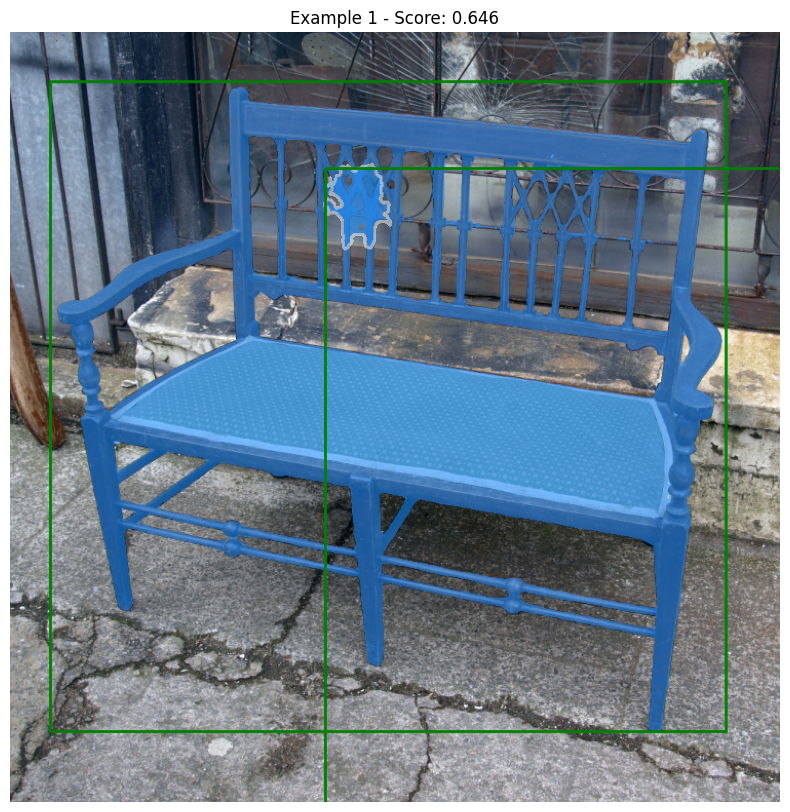

(array([[[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]],
       shape=(1, 750, 750)),
 array([0.6464017], dtype=float32),
 array([[[-13.389426 , -14.479427 , -14.085745 , ..., -12.93778  ,
          -12.729111 ,  -9.8806925],
         [-15.898105 , -17.295408 , -16.508211 , ..., -14.921341 ,
          -14.705492 , -12.641271 ],
         [-14.714643 , -15.670784 , -17.434252 , ..., -14.573309 ,
          -14.81947  , -12.430836 ],
         ...,
         [-13.987307 , -13.786337 , -14.590984 , ..., -14.507313 ,
          -13.745885 , -13.284087 ],
         [-14.350672 , -15.106746 , -16.367243 , ..., -13.979873 ,
          -14.473227 , -13.806555 ],
         [-13.550726 , -13.671428 , -

In [ ]:
model_type = 'vit_l'
checkpoint_path= '/u/ctran3/Sam_quantization/pretrained_checkpoint/sam_hq_vit_l.pth'
observer = EnergyObserver(module_list=(nn.Linear,))

sam = sam_model_registry[model_type](checkpoint=checkpoint_path).to('cuda')
predictor = SamPredictor(sam)
observer.register_energy_hook(predictor.model)

# inference video
apply_energy_observer(predictor.model)

observer.inference_image(predictor, show_image=True, image_dir='demo/hq_sam_result/example2_0.png')


In [10]:
def get_activation_boxplot(
    high_activations:torch.Tensor, 
    low_activations:torch.Tensor, 
    ax,
    title:str, max_channels=64, offset=0, show_plot=True
):
    
    high_data = to_numpy(high_activations.reshape(-1, high_activations.shape[-1])[:, offset:offset+max_channels])
    low_data = to_numpy(low_activations.reshape(-1, low_activations.shape[-1])[:, offset:offset+max_channels])

    high_channel_names = np.repeat(np.array([f"{i+1}" for i in  range(max_channels)]), high_data.shape[0])
    low_channel_names = np.repeat(np.array([f"{i+1}" for i in  range(max_channels)]), low_data.shape[0])
    high_data = high_data.flatten(order='F')
    low_data = low_data.flatten(order='F')
    types = ['high']*(high_data.shape[0])+['low']*(low_data.shape[0])

    df = pd.DataFrame({
        'values':  np.concatenate([high_data, low_data]),
        'channel': np.concatenate([high_channel_names, low_channel_names]),
        'types':  types,
    }) 

    # Create Plotly violin plot
    sns.violinplot(
        df, 
        ax=ax,
        x='channel', 
        y='values', 
        hue='types',
        split=True,
        inner='quart'
    )
    # fig.show()
    
    # Update layout for better appearance
    return fig

score_map (25, 196)
attention_input torch.Size([25, 196, 1024])
score_map (25, 196)
attention_input torch.Size([25, 196, 1024])
score_map (25, 196)
attention_input torch.Size([25, 196, 1024])
score_map (25, 196)
attention_input torch.Size([25, 196, 1024])
score_map (25, 196)
attention_input torch.Size([25, 196, 1024])
score_map (25, 196)
attention_input torch.Size([25, 196, 1024])
score_map (25, 196)
attention_input torch.Size([25, 196, 1024])
score_map (25, 196)
attention_input torch.Size([25, 196, 1024])
score_map (25, 196)
attention_input torch.Size([25, 196, 1024])
score_map (25, 196)
attention_input torch.Size([25, 196, 1024])
score_map (25, 196)
attention_input torch.Size([25, 196, 1024])
score_map (25, 196)
attention_input torch.Size([25, 196, 1024])
score_map (25, 196)
attention_input torch.Size([25, 196, 1024])
score_map (25, 196)
attention_input torch.Size([25, 196, 1024])
score_map (25, 196)
attention_input torch.Size([25, 196, 1024])
score_map (25, 196)
attention_input torc

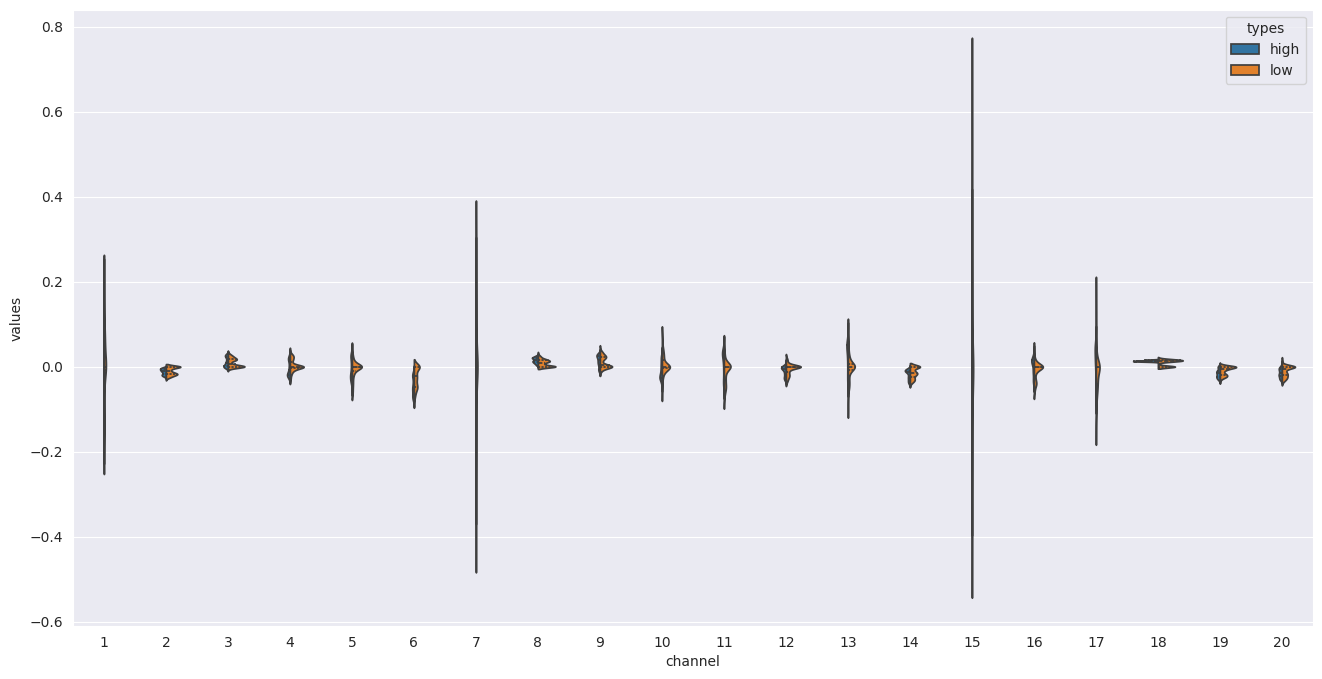

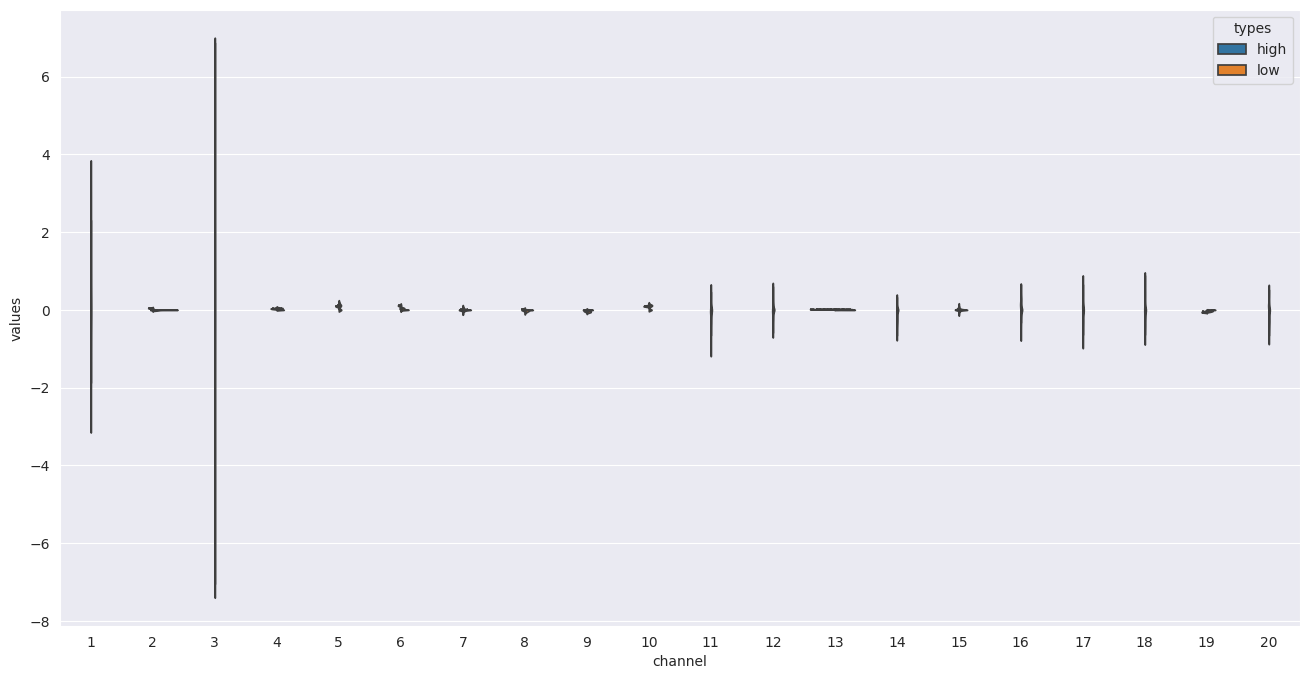

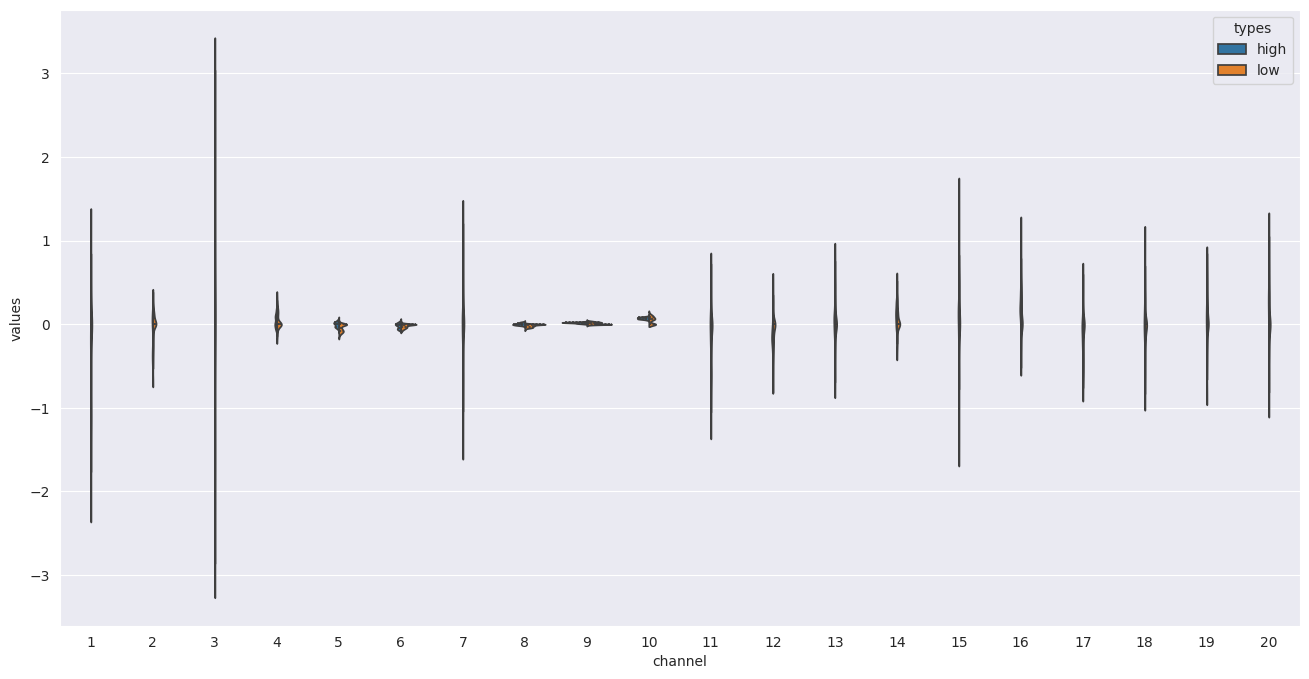

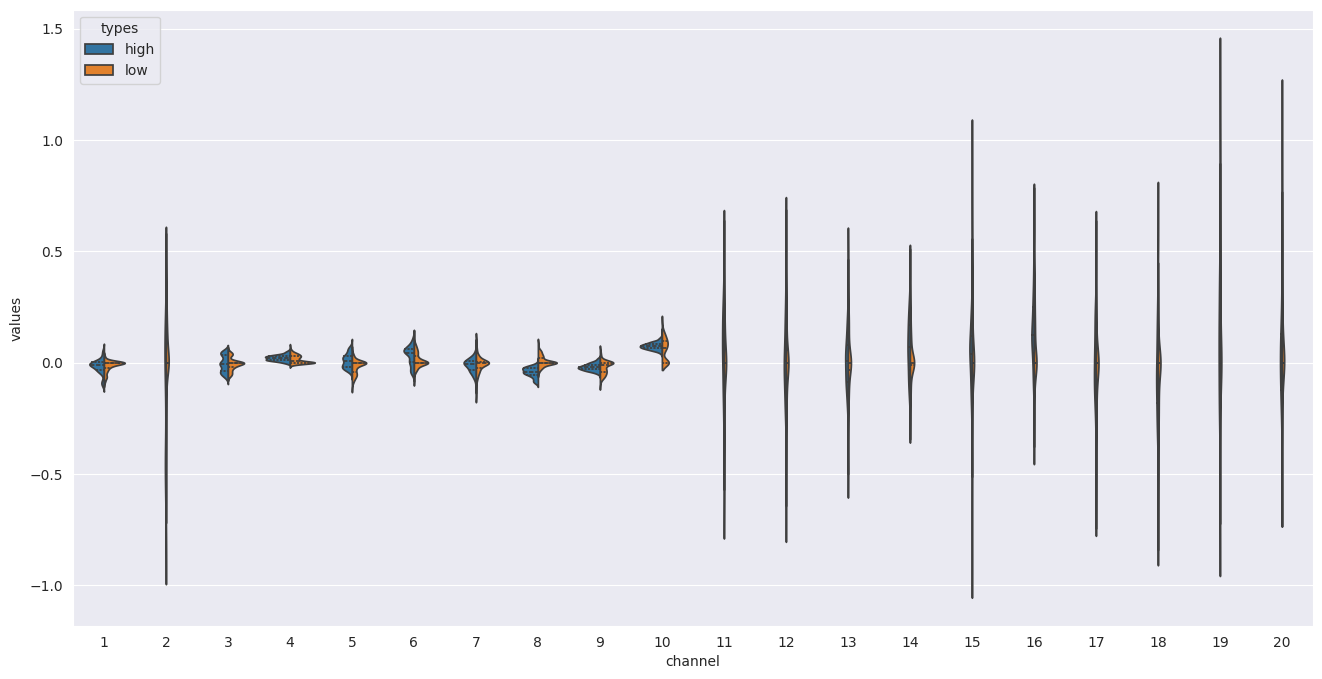

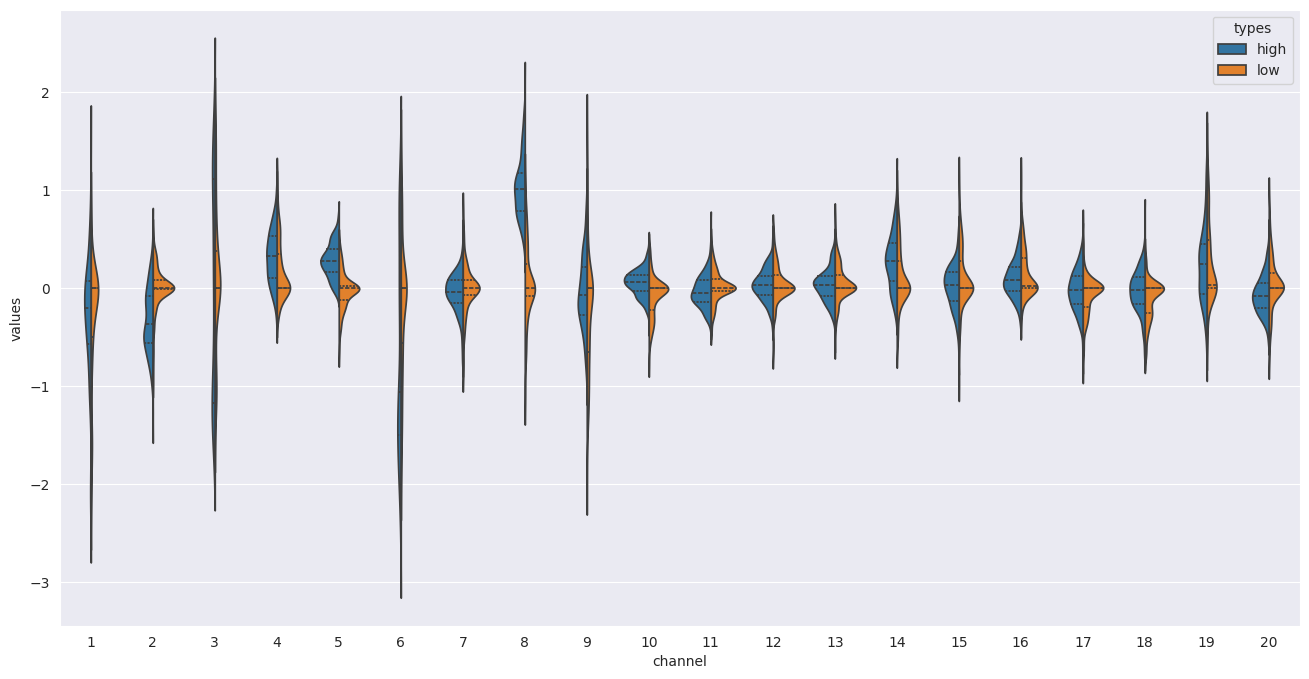

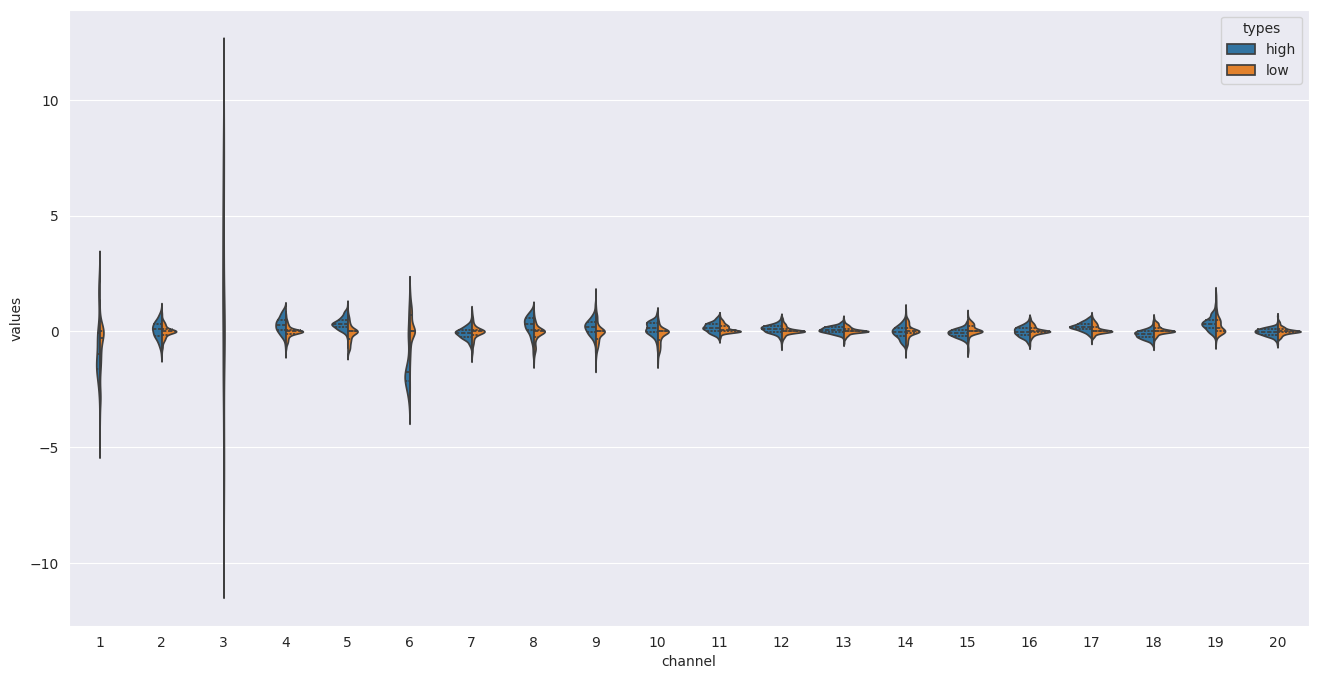

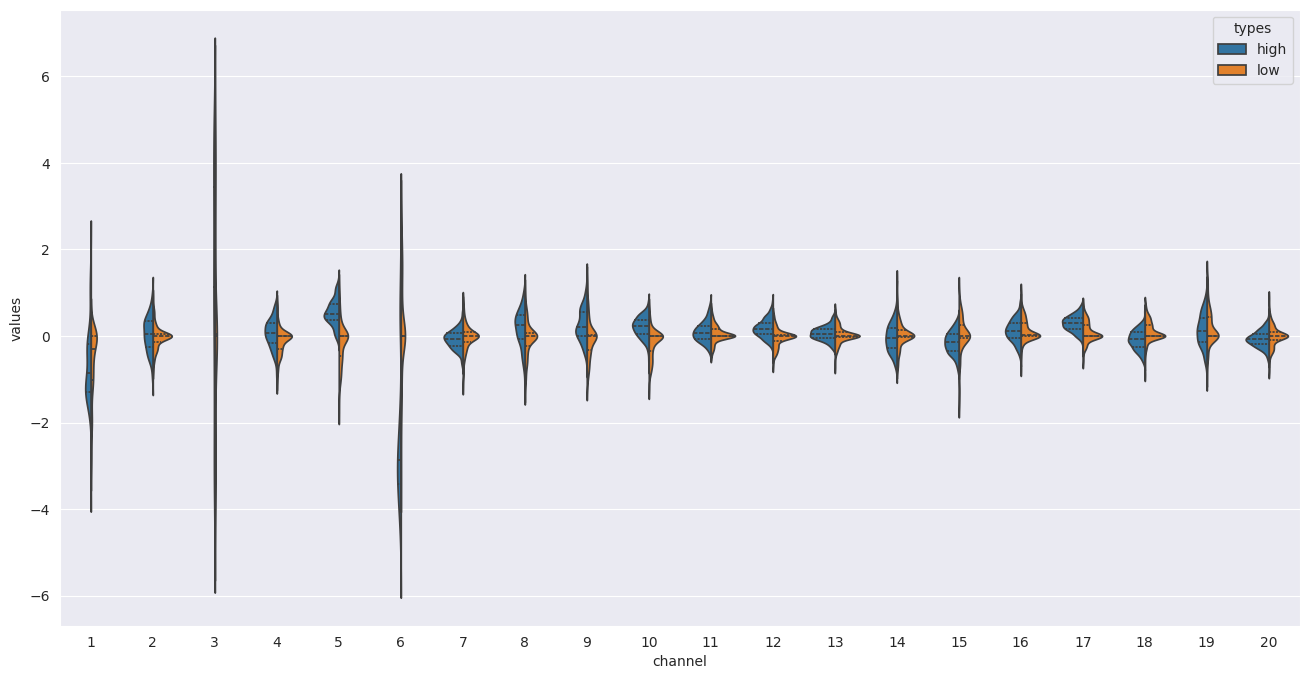

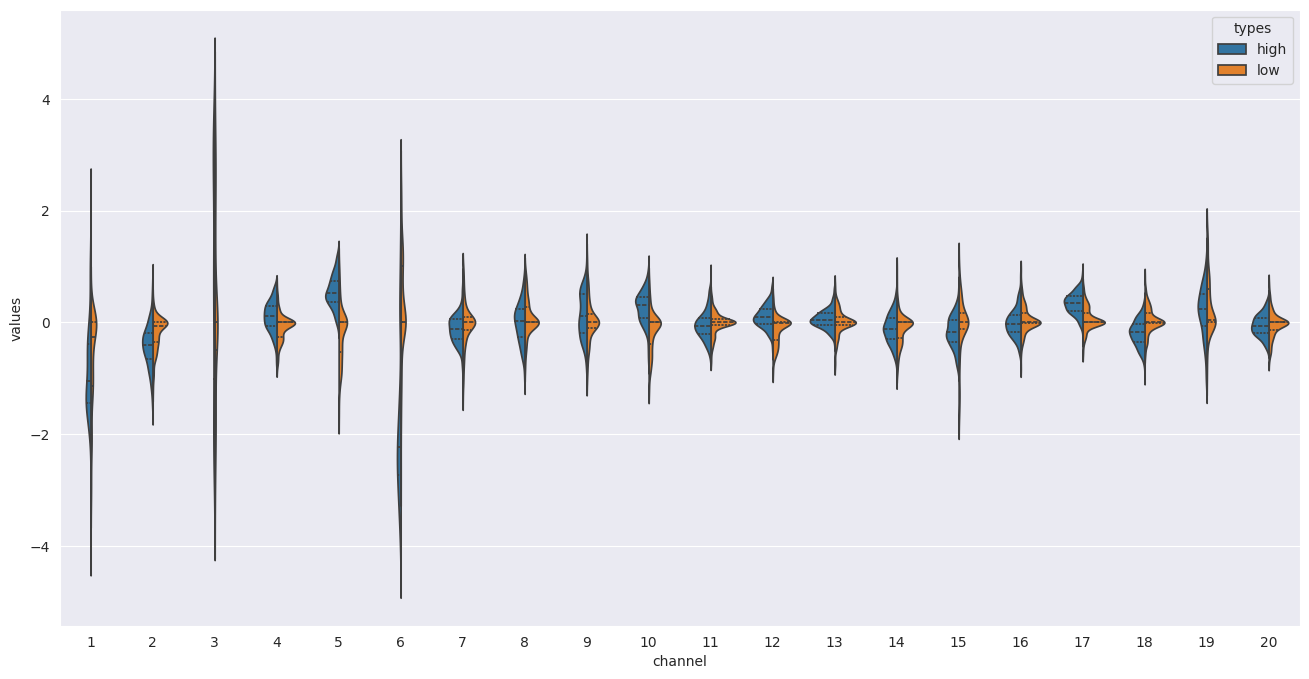

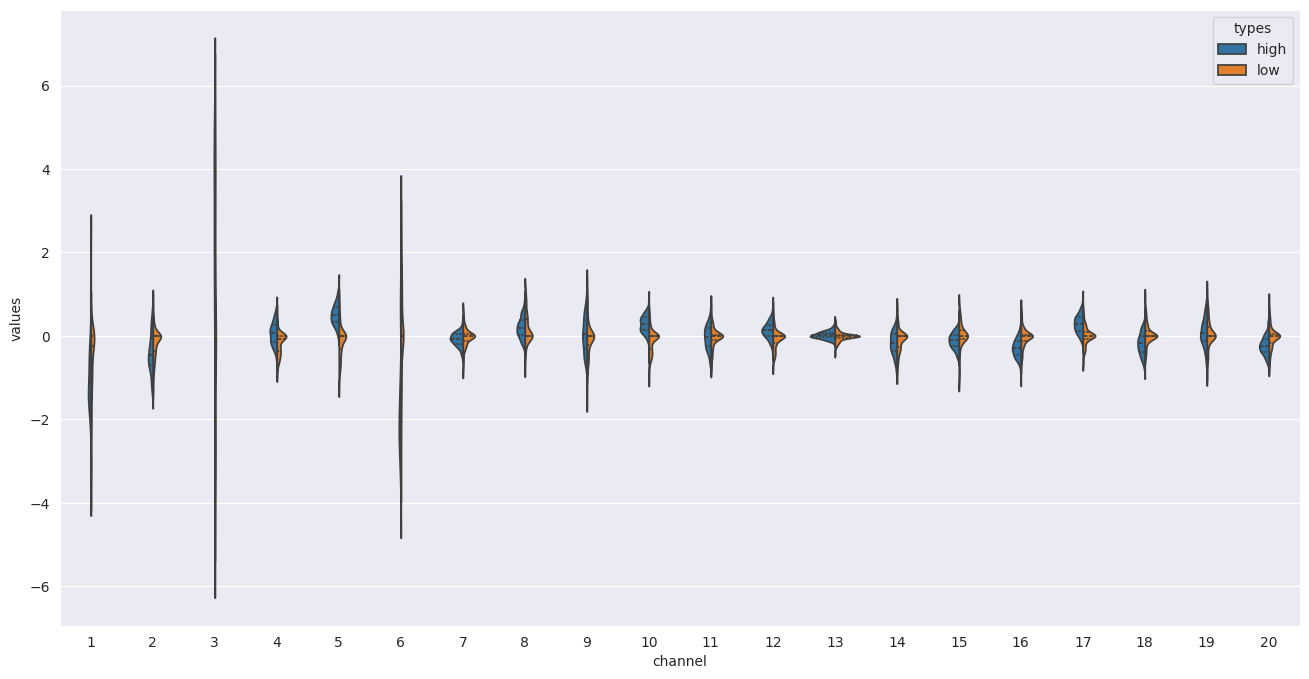

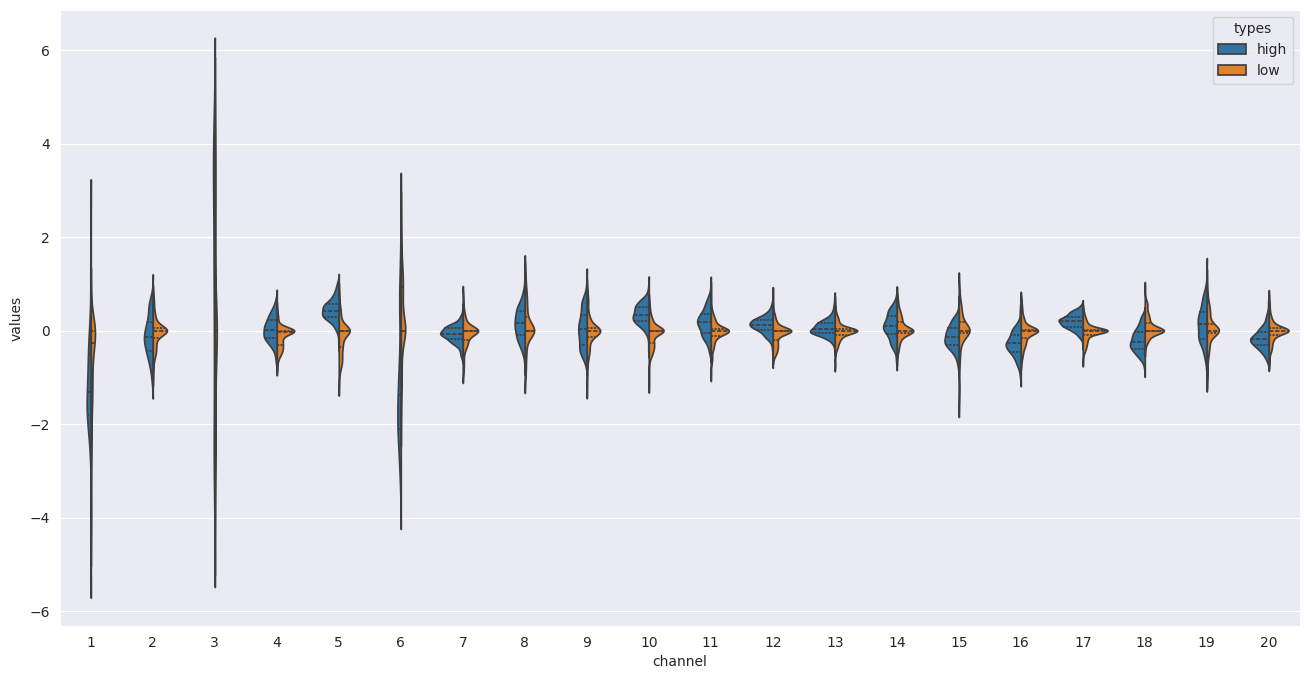

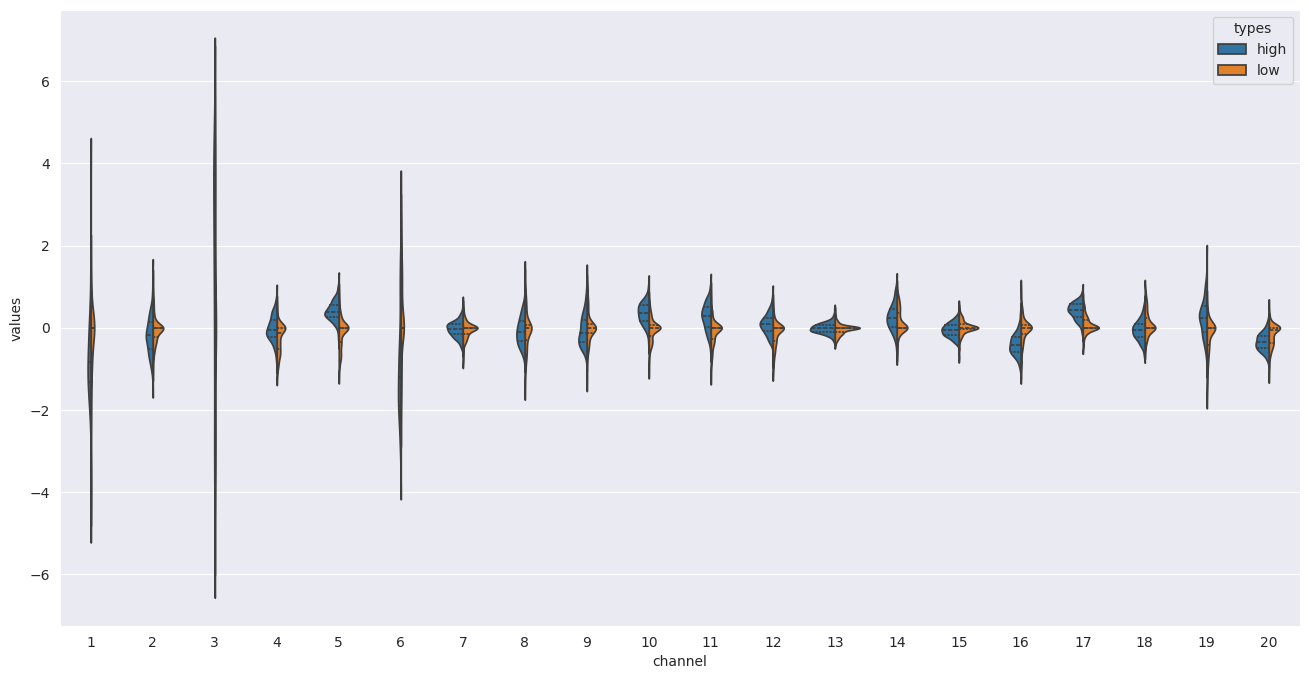

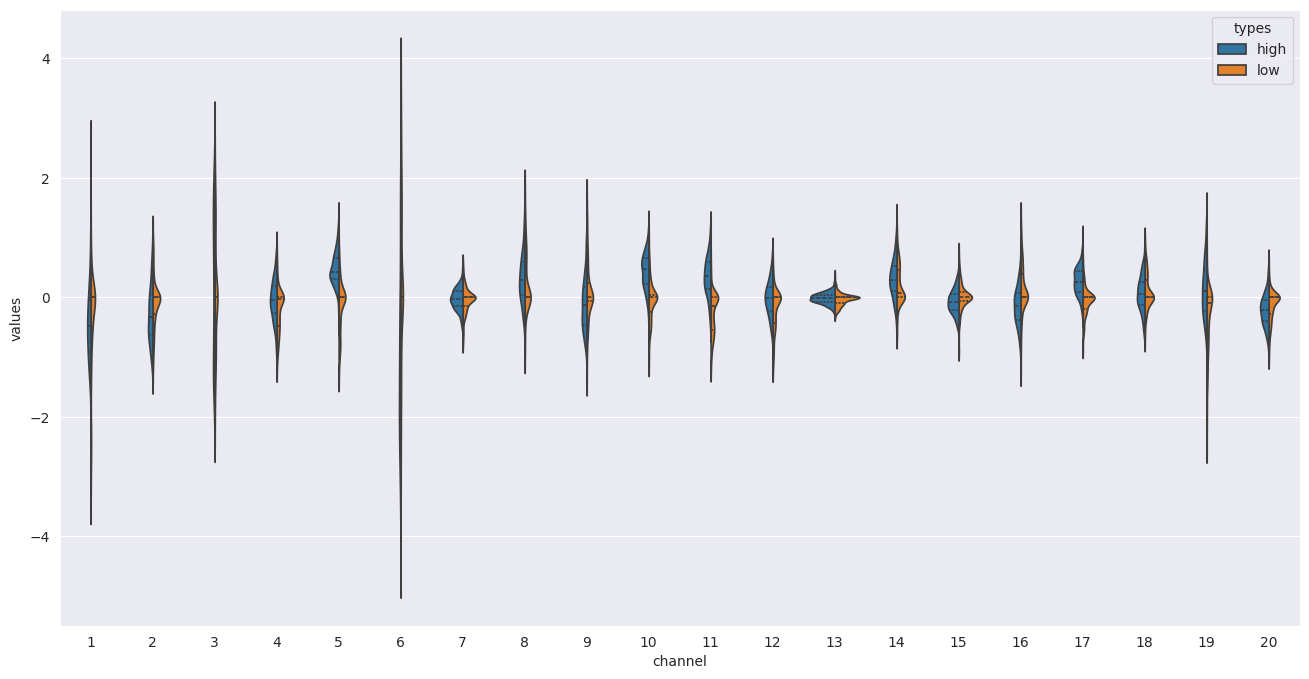

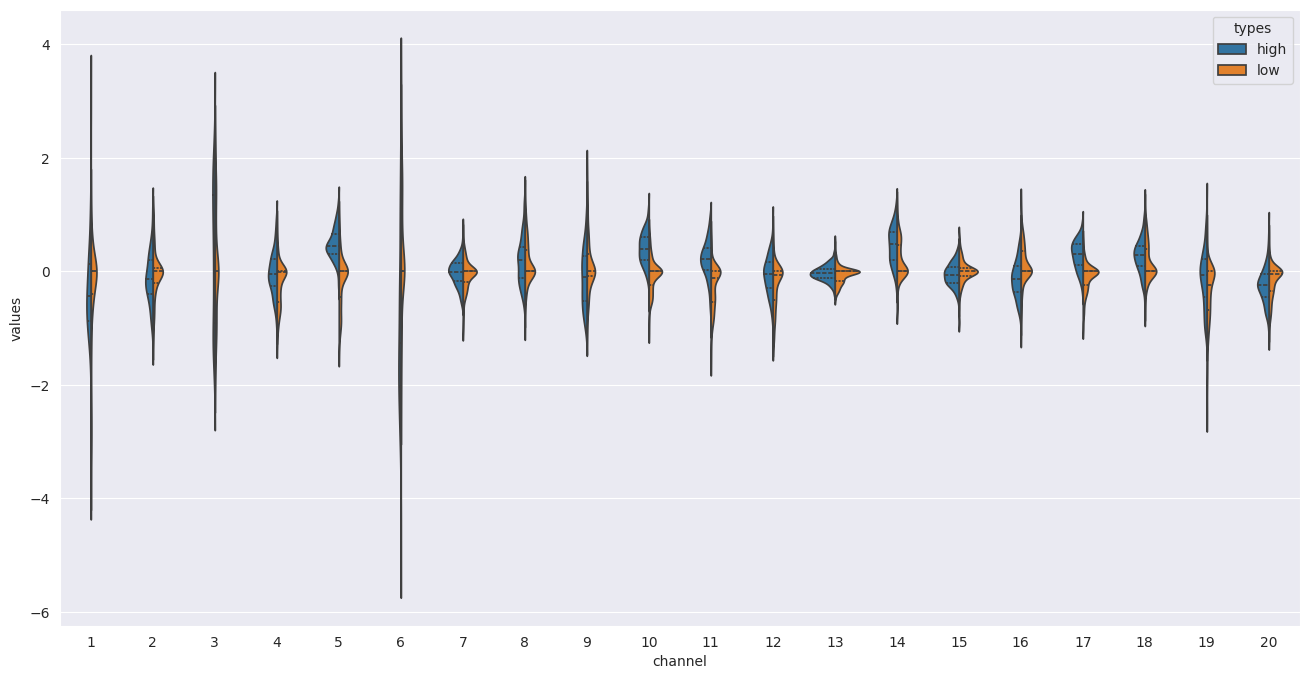

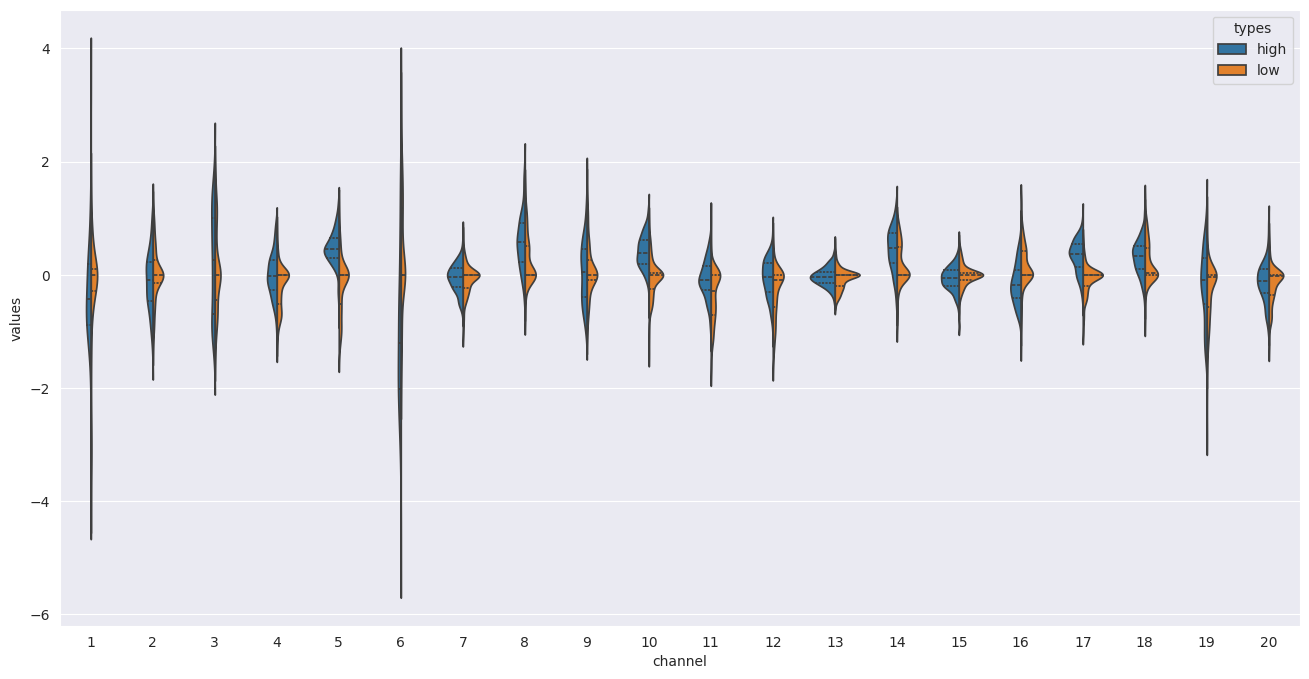

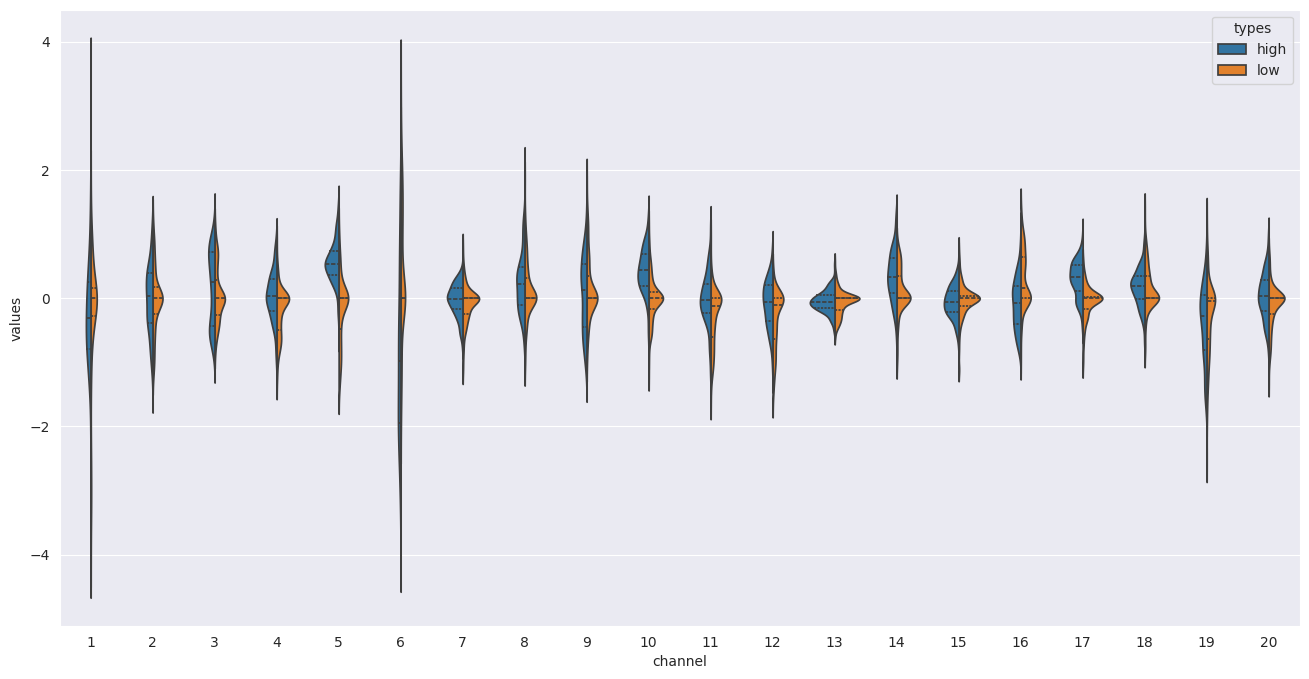

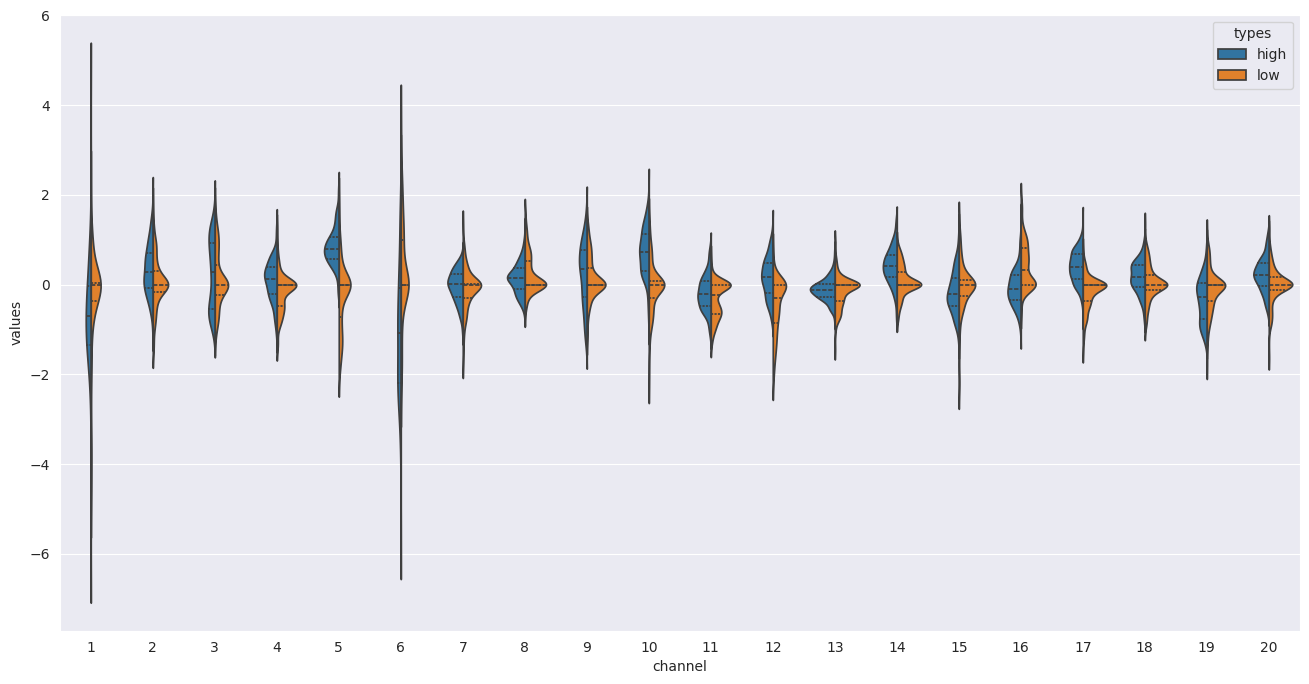

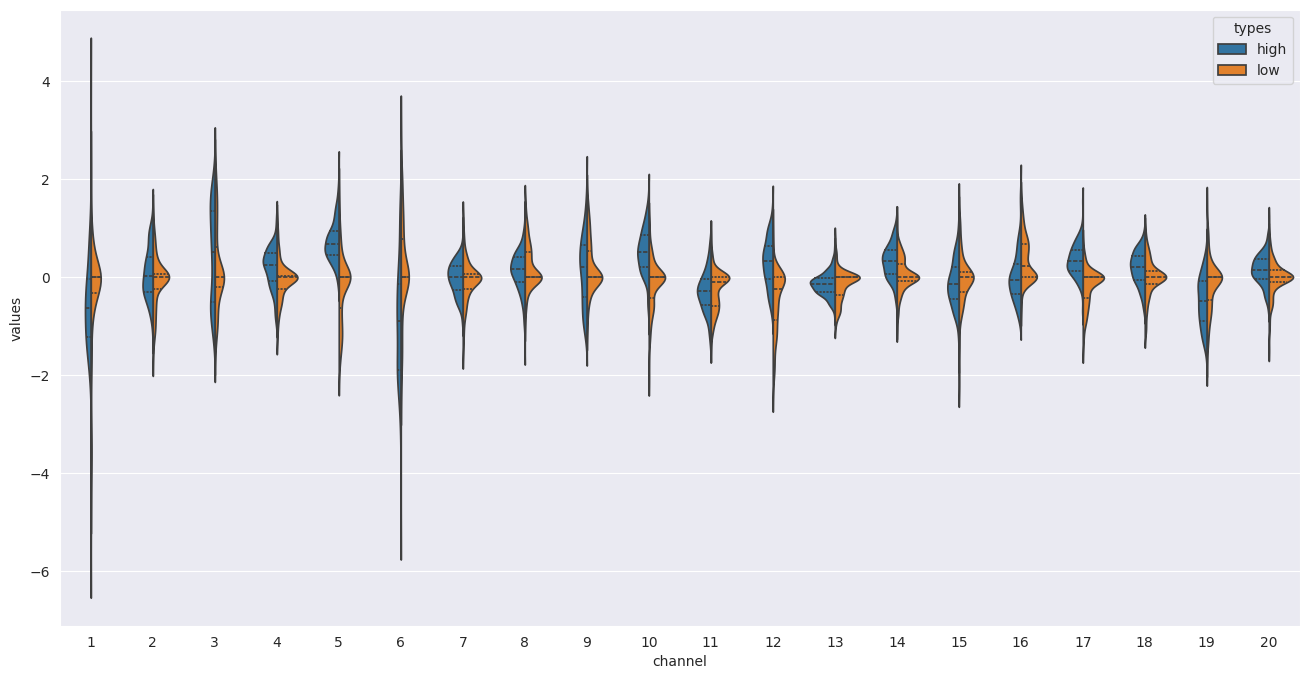

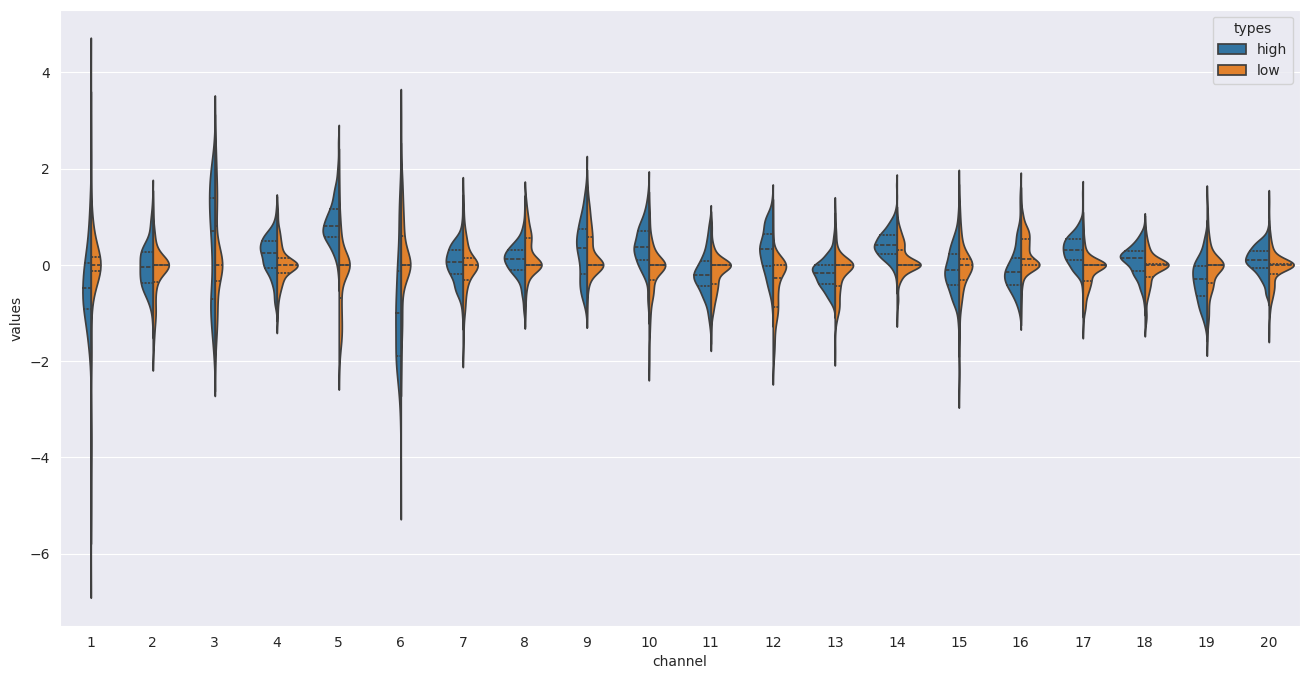

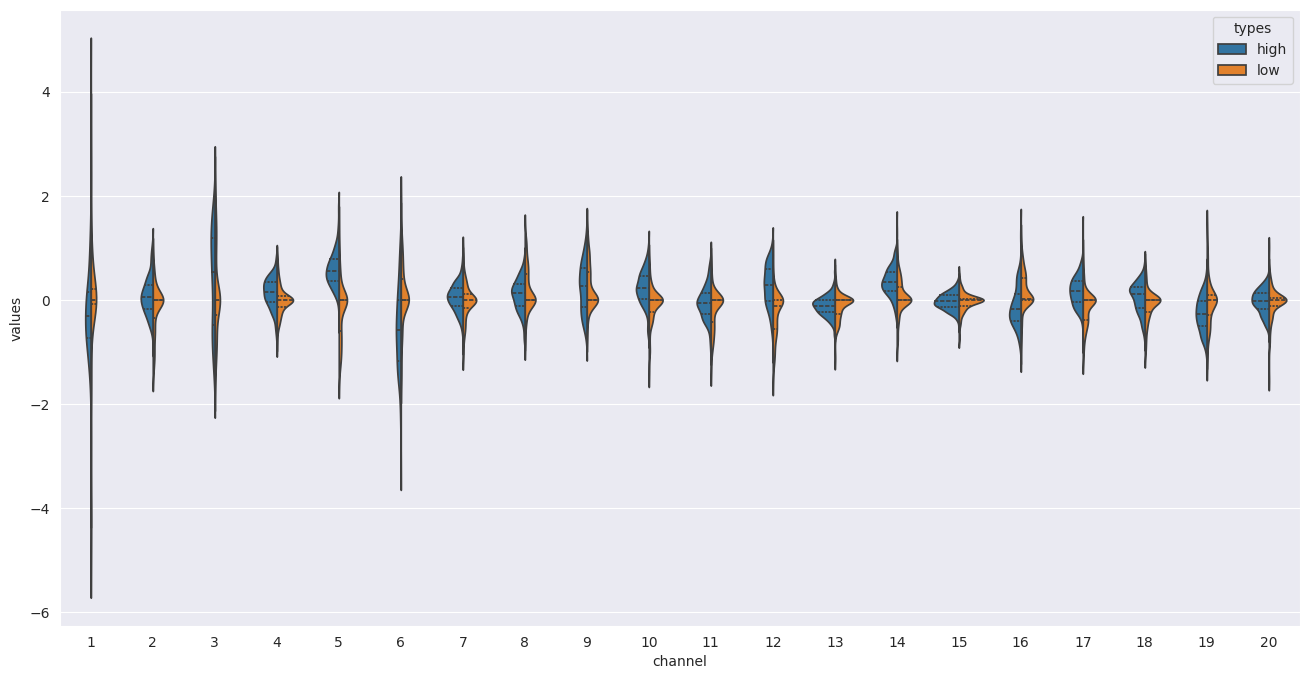

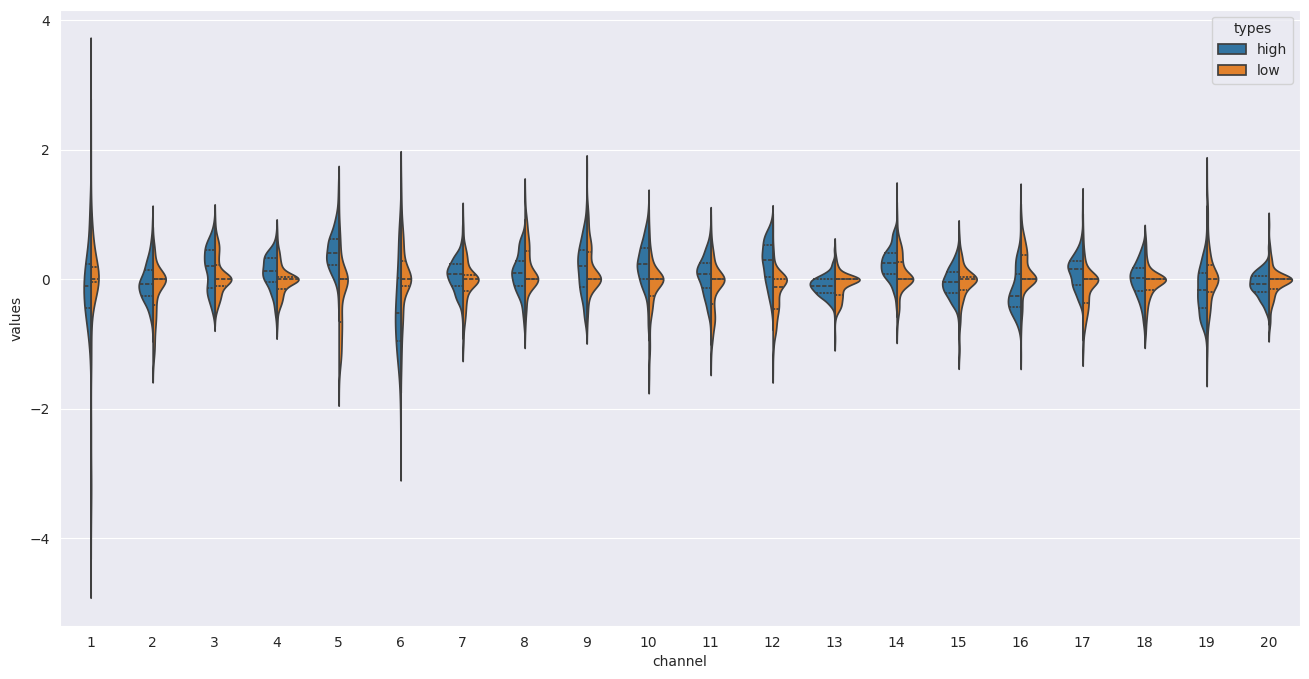

In [27]:

# Plotly Histogram Examples
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')

# Generate sample data for demonstration
np.random.seed(42)

# Example 1: Simple histogram with plotly express



n_bins = 200
min = -10.0
max = 10.0


for i in range(len(BlockObserver.observer_state['attn_input'])):

    attention_input = BlockObserver.observer_state['attn_input'][i]
    attention_input = attention_input.reshape(-1, attention_input.shape[1] * attention_input.shape[2], attention_input.shape[-1])
    # attention_input = BlockObserver.observer_state['q'][i]
    # head_idx =2
    # attention_input = AttnObserver.observer_state['q'][i]
    # attention_input = attention_input[:, : , head_idx, :]
    # attention_input = AttnObserver.observer_state['v'][i]
    # print(attention_input.shape)
    score_map = BlockObserver.observer_state['energy_map'][i]
    # score_map = AttnObserver.observer_state['q_E'][i]
    # score_map = AttnObserver.observer_state['k_E'][i]
    # score_map = AttnObserver.observer_state['q_E'][i]
    score_map = score_map.reshape(-1, score_map.shape[1] *  score_map.shape[2])
    print('score_map', score_map.shape)
    print('attention_input', attention_input.shape)
    score_map_original = BlockObserver.observer_state['energy_map'][i]
    
    # BlockObserver.show_energy_map(score_map) 
    # fig = px.histogram(score_map.flatten(), nbins=100, title="Energy distribution")
    # fig.show()
    
    
#     q = np.array([25, 75])
    # score_map = score_map.squeeze().reshape(score_map.shape[0],  -1)
    # score_mean = score_map.mean(-1)

#     # score_type = np.percentile(score_map, q, axis=-1, )
    # idx = score_map.flatten().argsort(-1)
    high_idx =  torch.topk(torch.from_numpy(score_map), dim=-1, k=10).indices # [B, M* N] 
    low_idx =  torch.topk(torch.from_numpy(score_map), dim=-1, k=10, largest=False).indices # [B, M* N] 
    high_input = torch.gather(attention_input.cpu(), dim=1, index=high_idx[..., None].expand(-1, high_idx.shape[-1], attention_input.shape[-1]))
    low_input = torch.gather(attention_input.cpu(), dim=1, index=low_idx[..., None].expand(-1, low_idx.shape[-1], attention_input.shape[-1]))
    fig, ax = plt.subplots(1,1, figsize=(16,8))
    
    get_activation_boxplot(high_input, low_input, ax=ax,title='High vs Low Energy Activation Distribution', max_channels=20, offset=0)
    # get_activation_boxplot(low_input,  'low', axes[1], max_channels=10,offset=150)
    # get_activation_boxplot(high_input_fft.real, 'high_fft', axes[1][0])
    # get_activation_boxplot(low_input_fft.real, 'low_fft', axes[1][1])
# BlockObserver.clear_dict()
# AttnObserver.clear_dict()

In [ ]:
# Simplified RTN Quantization with MSE Only

from torch.nn import attention


def simple_rtn_quantize(x: torch.Tensor, bits: int = 8) -> torch.Tensor:
    """
    Simple RTN quantization function
    
    Args:
        x: Input tensor
        bits: Number of bits for quantization
        
    Returns:
        Quantized and dequantized tensor
    """
    # Compute scale and zero point
    x_min = x.min()
    x_max = x.max()
    x_absmax = torch.max(torch.abs(x_min), torch.abs(x_max))
    
    # Symmetric quantization
    scale = x_absmax / (2 ** (bits - 1))
    zero_point = torch.zeros_like(scale)
    
    # Quantize
    quantized = torch.round((x - zero_point) / scale)
    quantized = torch.clamp(quantized, -(2 ** (bits - 1)), (2 ** (bits - 1)) - 1)
    
    # Dequantize
    dequantized = quantized * scale + zero_point
    
    return dequantized

def compute_mse(original: torch.Tensor, quantized: torch.Tensor) -> float:

    return torch.mean((original - quantized) ** 2).item()

def analyze_energy_quantization_mse(high_energy_input: torch.Tensor, 
                                  low_energy_input: torch.Tensor, 
                                  bits: int = 8) -> dict:
  
    # Quantize both inputs
    high_quantized = simple_rtn_quantize(high_energy_input, bits)
    low_quantized = simple_rtn_quantize(low_energy_input, bits)
    
    # Compute MSE
    high_mse = compute_mse(high_energy_input, high_quantized)
    low_mse = compute_mse(low_energy_input, low_quantized)
    
    return {
        'high_energy_mse': high_mse,
        'low_energy_mse': low_mse,
        'mse_ratio': low_mse / high_mse if high_mse > 0 else float('inf')
    }

# Example usage with your existing data
if BlockObserver.observer_state:
    print("Analyzing quantization MSE for high vs low energy inputs...")
    
    # Use first layer data
    for i in range(len(BlockObserver.observer_state['energy_map'])):
        print('='* 100, f'layer{i}', '='*100)
        # Get attention data
        attention_input = BlockObserver.observer_state['attn_input'][i]  # First layer
        energy_map = torch.from_numpy(BlockObserver.observer_state['energy_map'][i])
        
        # Reshape for processing
        B, H, W, C = attention_input.shape
        print(attention_input.shape)
        attention_input = attention_input.reshape(B, H*W, C)
        energy_flat = energy_map.reshape(B, H*W)
        
        # Select high and low energy tokens (top 20 each)
        _, high_idx = torch.topk(energy_flat, k=50, dim=-1,largest=True)
        _, low_idx = torch.topk(energy_flat, k=50, dim=-1,largest=False)
        
        high_input = torch.gather(attention_input.cpu(), dim=1, index=high_idx[..., None].expand(-1, high_idx.shape[-1], attention_input.shape[-1]))
        low_input = torch.gather(attention_input.cpu(), dim=1, index=low_idx[..., None].expand(-1, low_idx.shape[-1], attention_input.shape[-1]))
        
        
        # Analyze with different bit precisions
        for bits in [8, 4, 2]:
            results = analyze_energy_quantization_mse(high_input, low_input, bits)
            print(f"{bits}-bit quantization:")
            print(f"  High energy MSE: {results['high_energy_mse']:.6f}")
            print(f"  Low energy MSE:  {results['low_energy_mse']:.6f}")
            print(f"  MSE ratio (Low/High): {results['mse_ratio']:.3f}")
            print()
else:
    print("No observer data available. Run inference first to get attention and energy data.")


Analyzing quantization MSE for high vs low energy inputs...
==================================================================================================== layer0 ====================================================================================================
torch.Size([25, 14, 14, 1024])
8-bit quantization:
  High energy MSE: 0.000095
  Low energy MSE:  0.000086
  MSE ratio (Low/High): 0.903

4-bit quantization:
  High energy MSE: 0.003766
  Low energy MSE:  0.004800
  MSE ratio (Low/High): 1.274

2-bit quantization:
  High energy MSE: 0.005466
  Low energy MSE:  0.007552
  MSE ratio (Low/High): 1.381

==================================================================================================== layer1 ====================================================================================================
torch.Size([25, 14, 14, 1024])
8-bit quantization:
  High energy MSE: 0.000187
  Low energy MSE:  0.000111
  MSE ratio (Low/High): 0.592

4-bit quantization:
  High energ

In [ ]:
# Channel-wise RTN Quantization with MSE

def channel_wise_rtn_quantize(x: torch.Tensor, bits: int = 8) -> torch.Tensor:
    """
    Channel-wise RTN quantization function
    
    Args:
        x: Input tensor with shape (..., C) where C is the channel dimension
        bits: Number of bits for quantization
        
    Returns:
        Quantized and dequantized tensor
    """
    # Ensure we have a channel dimension
    if x.dim() < 2:
        raise ValueError("Input tensor must have at least 2 dimensions for channel-wise quantization")
    
    # Get the last dimension as channel dimension
    original_shape = x.shape
    x_reshaped = x.reshape(-1, x.shape[-1])  # (N, C)
    
    # Compute channel-wise scale and zero point
    x_min = x_reshaped.min(dim=0, keepdim=True)[0]  # (1, C)
    x_max = x_reshaped.max(dim=0, keepdim=True)[0]  # (1, C)
    x_absmax = torch.max(torch.abs(x_min), torch.abs(x_max))  # (1, C)
    
    # Symmetric quantization - scale per channel
    scale = x_absmax / (2 ** (bits - 1))  # (1, C)
    zero_point = torch.zeros_like(scale)  # (1, C)
    
    # Quantize channel-wise
    quantized = torch.round((x_reshaped - zero_point) / scale)  # (N, C)
    quantized = torch.clamp(quantized, -(2 ** (bits - 1)), (2 ** (bits - 1)) - 1)
    
    # Dequantize channel-wise
    dequantized = quantized * scale + zero_point  # (N, C)
    
    # Reshape back to original shape
    dequantized = dequantized.reshape(original_shape)
    
    return dequantized

def analyze_energy_quantization_mse_channel_wise(high_energy_input: torch.Tensor, 
                                               low_energy_input: torch.Tensor, 
                                               bits: int = 8) -> dict:
    """
    Analyze MSE for high vs low energy inputs with channel-wise RTN quantization
    
    Args:
        high_energy_input: High energy input tensor
        low_energy_input: Low energy input tensor
        bits: Number of bits for quantization
        
    Returns:
        Dictionary with MSE values
    """
    # Quantize both inputs using channel-wise quantization
    high_quantized = channel_wise_rtn_quantize(high_energy_input, bits)
    low_quantized = channel_wise_rtn_quantize(low_energy_input, bits)
    
    # Compute MSE
    high_mse = compute_mse(high_energy_input, high_quantized)
    low_mse = compute_mse(low_energy_input, low_quantized)
    
    return {
        'high_energy_mse': high_mse,
        'low_energy_mse': low_mse,
        'mse_ratio': low_mse / high_mse if high_mse > 0 else float('inf')
    }

# Compare tensor-wise vs channel-wise quantization
def compare_quantization_methods(high_energy_input: torch.Tensor, 
                               low_energy_input: torch.Tensor, 
                               bits: int = 8) -> dict:
    """
    Compare tensor-wise vs channel-wise quantization MSE
    
    Args:
        high_energy_input: High energy input tensor
        low_energy_input: Low energy input tensor
        bits: Number of bits for quantization
        
    Returns:
        Dictionary comparing both methods
    """
    # Tensor-wise quantization (original)
    high_quantized_tensor = simple_rtn_quantize(high_energy_input, bits)
    low_quantized_tensor = simple_rtn_quantize(low_energy_input, bits)
    
    high_mse_tensor = compute_mse(high_energy_input, high_quantized_tensor)
    low_mse_tensor = compute_mse(low_energy_input, low_quantized_tensor)
    
    # Channel-wise quantization (new)
    high_quantized_channel = channel_wise_rtn_quantize(high_energy_input, bits)
    low_quantized_channel = channel_wise_rtn_quantize(low_energy_input, bits)
    
    high_mse_channel = compute_mse(high_energy_input, high_quantized_channel)
    low_mse_channel = compute_mse(low_energy_input, low_quantized_channel)
    
    return {
        'tensor_wise': {
            'high_energy_mse': high_mse_tensor,
            'low_energy_mse': low_mse_tensor,
            'mse_ratio': low_mse_tensor / high_mse_tensor if high_mse_tensor > 0 else float('inf')
        },
        'channel_wise': {
            'high_energy_mse': high_mse_channel,
            'low_energy_mse': low_mse_channel,
            'mse_ratio': low_mse_channel / high_mse_channel if high_mse_channel > 0 else float('inf')
        }
    }

# Example usage with your existing data
if AttnObserver.observer_state and BlockObserver.observer_state:
    print("Analyzing channel-wise quantization MSE for high vs low energy inputs...")
    
    # Use first layer data
    for i in range(len(BlockObserver.observer_state['energy_map'])):
        # Get attention data
        attention_input = BlockObserver.observer_state['attn_input'][i]  # First layer
        energy_map = torch.from_numpy(BlockObserver.observer_state['energy_map'][i])
        
        # Reshape for processing
        B, H, W, C = attention_input.shape
        attention_input = attention_input.reshape(B, H*W, C)
        energy_flat = energy_map.reshape(B, H*W)
        
        # Select high and low energy tokens (top 20 each)
        _, high_idx = torch.topk(energy_flat, k=20, dim=-1,largest=True)
        _, low_idx = torch.topk(energy_flat, k=20, dim=-1,largest=False)
        
        high_input = torch.gather(attention_input.cpu(), dim=1, index=high_idx[..., None].expand(-1, high_idx.shape[-1], attention_input.shape[-1]))
        low_input = torch.gather(attention_input.cpu(), dim=1, index=low_idx[..., None].expand(-1, low_idx.shape[-1], attention_input.shape[-1]))
        
        print(f"Input shapes - High energy: {high_input.shape}, Low energy: {low_input.shape}")
        print(f"Channel dimension: {high_input.shape[-1]}")
        print()
        
        # Analyze with different bit precisions
        for bits in [ 4, 2]:
            print(f"{bits}-bit quantization:")
            
            # Compare both methods
            comparison = compare_quantization_methods(high_input, low_input, bits)
            
            print("  Tensor-wise quantization:")
            print(f"    High energy MSE: {comparison['tensor_wise']['high_energy_mse']:.6f}")
            print(f"    Low energy MSE:  {comparison['tensor_wise']['low_energy_mse']:.6f}")
            print(f"    MSE ratio (Low/High): {comparison['tensor_wise']['mse_ratio']:.3f}")
            
            print("  Channel-wise quantization:")
            print(f"    High energy MSE: {comparison['channel_wise']['high_energy_mse']:.6f}")
            print(f"    Low energy MSE:  {comparison['channel_wise']['low_energy_mse']:.6f}")
            print(f"    MSE ratio (Low/High): {comparison['channel_wise']['mse_ratio']:.3f}")
            
            # Show improvement
            tensor_high_mse = comparison['tensor_wise']['high_energy_mse']
            channel_high_mse = comparison['channel_wise']['high_energy_mse']
            tensor_low_mse = comparison['tensor_wise']['low_energy_mse']
            channel_low_mse = comparison['channel_wise']['low_energy_mse']
            
            high_improvement = (tensor_high_mse - channel_high_mse) / tensor_high_mse * 100
            low_improvement = (tensor_low_mse - channel_low_mse) / tensor_low_mse * 100
            
            print(f"  Channel-wise improvement:")
            print(f"    High energy: {high_improvement:.1f}% MSE reduction")
            print(f"    Low energy:  {low_improvement:.1f}% MSE reduction")
            print()
else:
    print("No observer data available. Run inference first to get attention and energy data.")


Analyzing channel-wise quantization MSE for high vs low energy inputs...
Input shapes - High energy: torch.Size([25, 20, 1024]), Low energy: torch.Size([25, 20, 1024])
Channel dimension: 1024

4-bit quantization:
  Tensor-wise quantization:
    High energy MSE: 0.003251
    Low energy MSE:  0.004778
    MSE ratio (Low/High): 1.470
  Channel-wise quantization:
    High energy MSE: 0.000103
    Low energy MSE:  0.000144
    MSE ratio (Low/High): 1.401
  Channel-wise improvement:
    High energy: 96.8% MSE reduction
    Low energy:  97.0% MSE reduction

2-bit quantization:
  Tensor-wise quantization:
    High energy MSE: 0.004895
    Low energy MSE:  0.008944
    MSE ratio (Low/High): 1.827
  Channel-wise quantization:
    High energy MSE: 0.001948
    Low energy MSE:  0.002424
    MSE ratio (Low/High): 1.244
  Channel-wise improvement:
    High energy: 60.2% MSE reduction
    Low energy:  72.9% MSE reduction

Input shapes - High energy: torch.Size([25, 20, 1024]), Low energy: torch.Size(

# T-SNE

In [ ]:
def t_sne_plot(high_input:torch.Tensor, low_input:torch.Tensor):

score_map (25, 196)
attention_input torch.Size([25, 196, 1024])


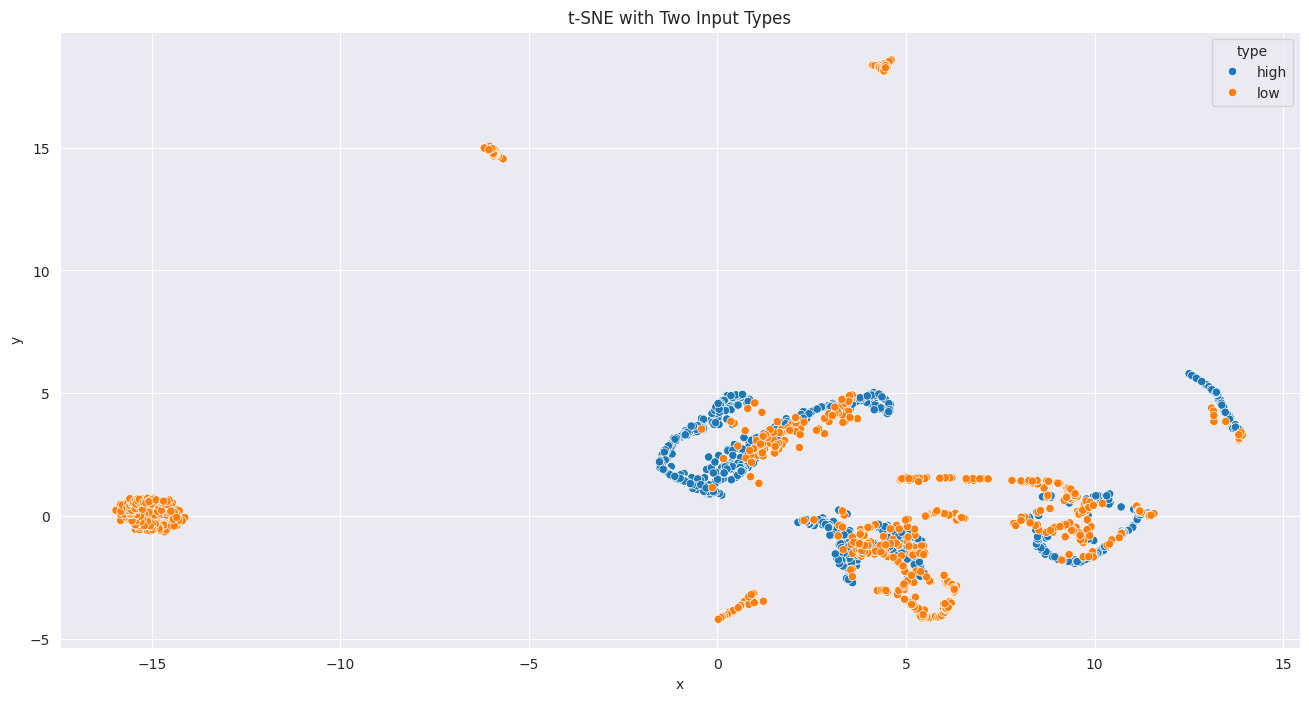

========== layer 0 =============
score_map (25, 196)
attention_input torch.Size([25, 196, 1024])


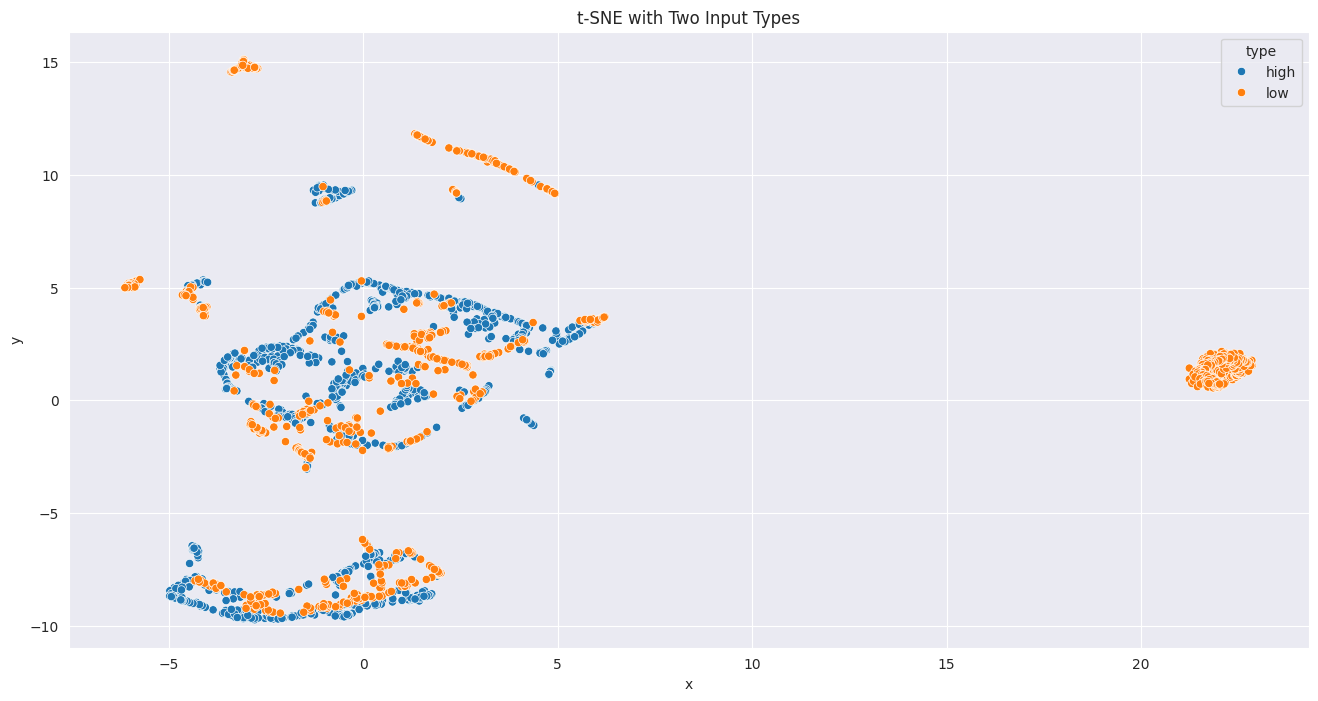

========== layer 1 =============
score_map (25, 196)
attention_input torch.Size([25, 196, 1024])


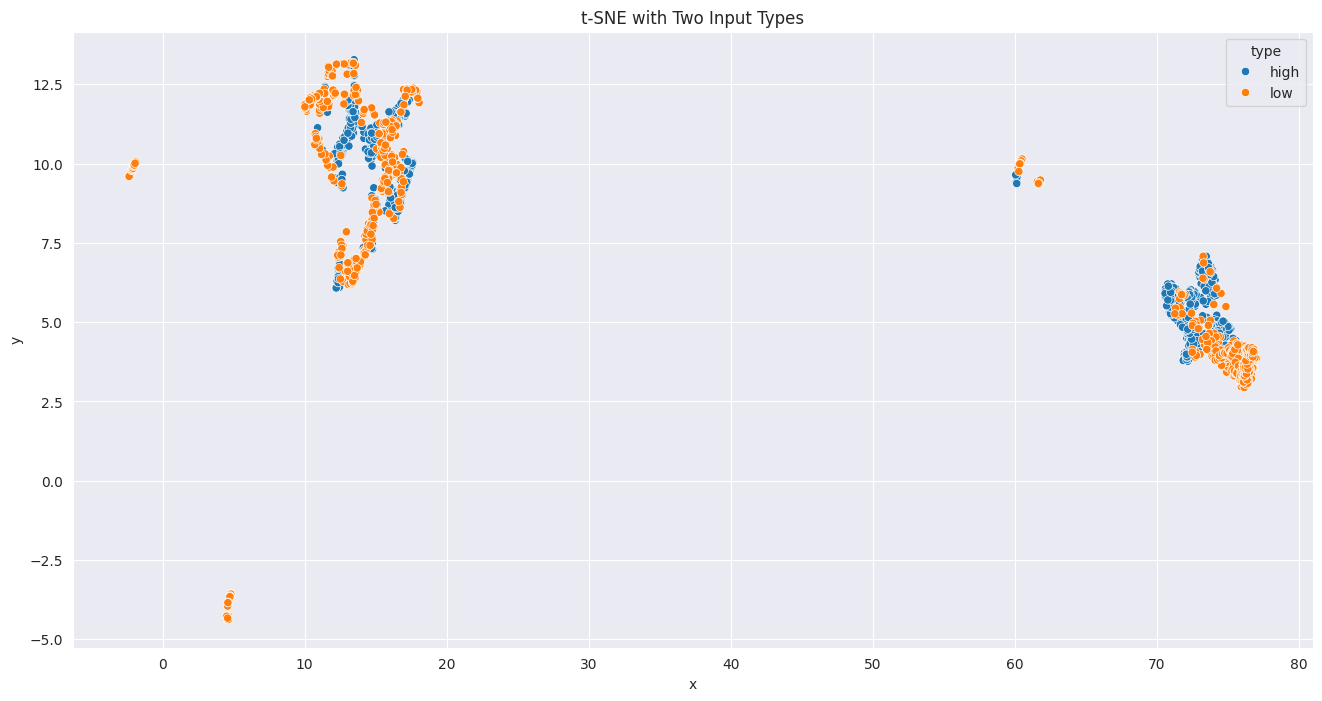

========== layer 2 =============
score_map (25, 196)
attention_input torch.Size([25, 196, 1024])


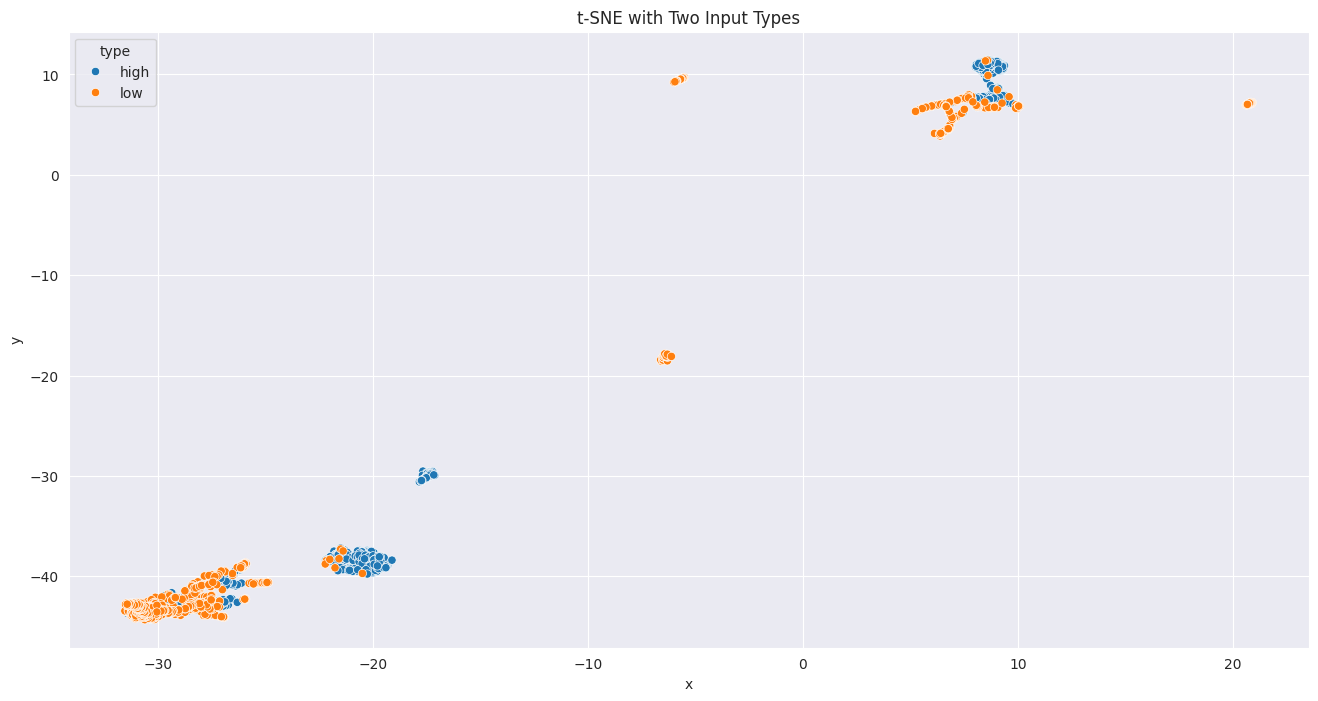

========== layer 3 =============
score_map (25, 196)
attention_input torch.Size([25, 196, 1024])


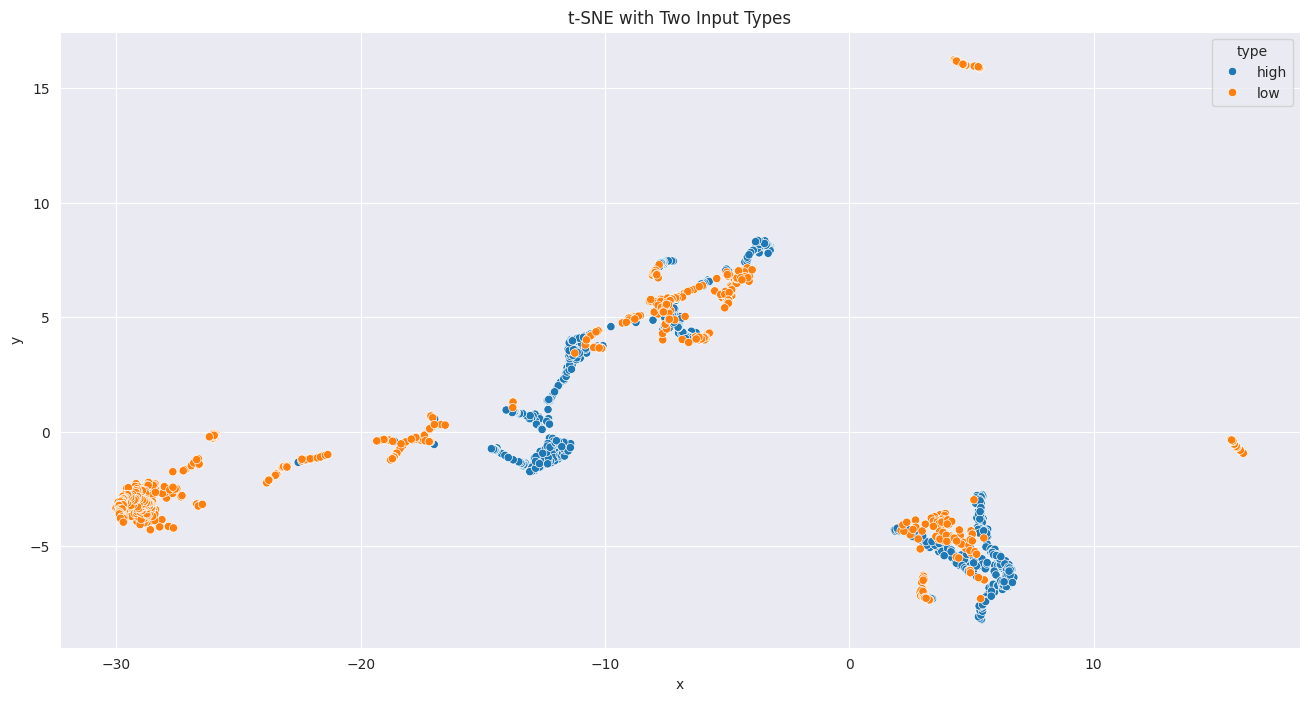

========== layer 4 =============
score_map (25, 196)
attention_input torch.Size([25, 196, 1024])


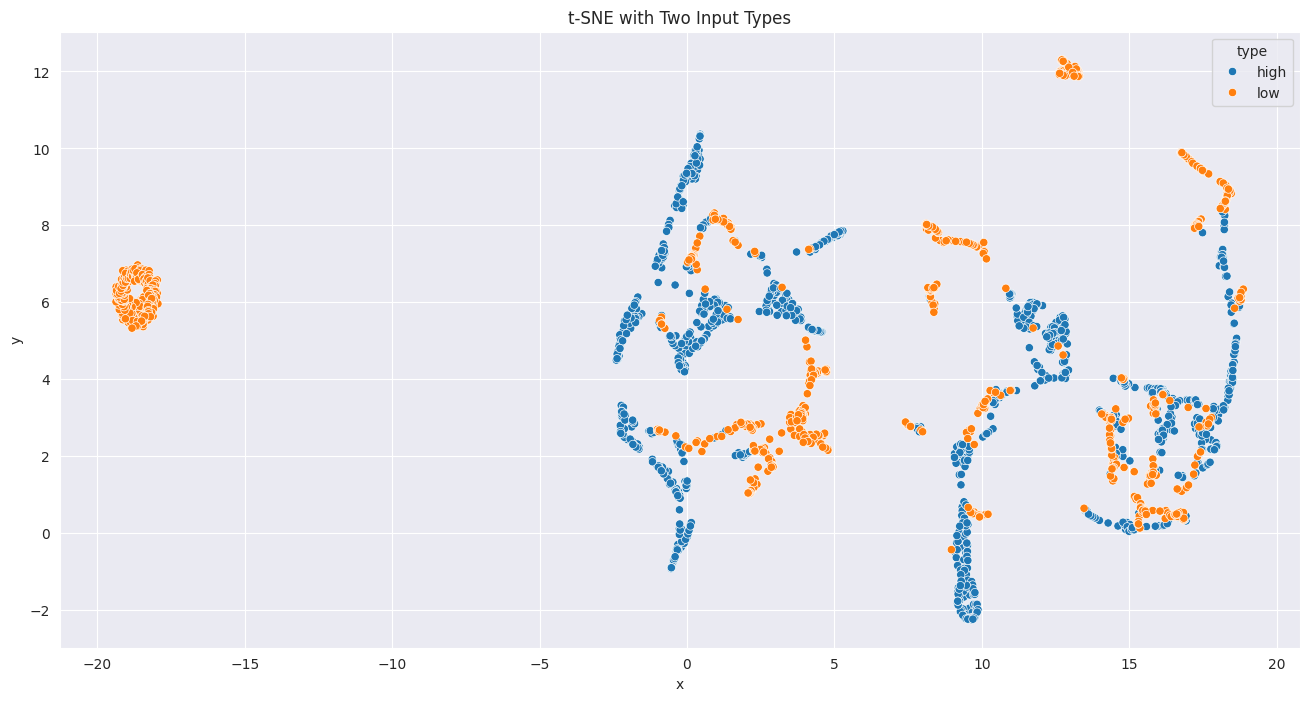

========== layer 5 =============
score_map (25, 196)
attention_input torch.Size([25, 196, 1024])


KeyboardInterrupt: 

In [21]:

# Plotly Histogram Examples
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE 
import umap.umap_ as umap
import seaborn as sns
sns.set_style('darkgrid')

# Generate sample data for demonstration
np.random.seed(42)

# Example 1: Simple histogram with plotly express



n_bins = 200
min = -10.0
max = 10.0


for i in range(len(BlockObserver.observer_state['attn_input'])):

    attention_input = BlockObserver.observer_state['attn_input'][i]
    attention_input = attention_input.reshape(-1, attention_input.shape[1] * attention_input.shape[2], attention_input.shape[-1])
    # attention_input = BlockObserver.observer_state['q'][i]
    # head_idx =2
    # attention_input = AttnObserver.observer_state['q'][i]
    # attention_input = attention_input[:, : , head_idx, :]
    # attention_input = AttnObserver.observer_state['v'][i]
    # print(attention_input.shape)
    score_map = BlockObserver.observer_state['energy_map'][i]
    # score_map = AttnObserver.observer_state['q_E'][i]
    # score_map = AttnObserver.observer_state['k_E'][i]
    # score_map = AttnObserver.observer_state['q_E'][i]
    score_map = score_map.reshape(-1, score_map.shape[1] *  score_map.shape[2])
    print('score_map', score_map.shape)
    print('attention_input', attention_input.shape)
    score_map_original = BlockObserver.observer_state['energy_map'][i]
    
    # BlockObserver.show_energy_map(score_map) 
    # fig = px.histogram(score_map.flatten(), nbins=100, title="Energy distribution")
    # fig.show()
    
    
#     q = np.array([25, 75])
    # score_map = score_map.squeeze().reshape(score_map.shape[0],  -1)
    # score_mean = score_map.mean(-1)

#     # score_type = np.percentile(score_map, q, axis=-1, )
    # idx = score_map.flatten().argsort(-1)
    high_idx =  torch.topk(torch.from_numpy(score_map), dim=-1, k=50).indices # [B, M* N] 
    low_idx =  torch.topk(torch.from_numpy(score_map), dim=-1, k=50, largest=False).indices # [B, M* N] 
    high_input = torch.gather(attention_input.cpu(), dim=1, index=high_idx[..., None].expand(-1, high_idx.shape[-1], attention_input.shape[-1]))
    low_input = torch.gather(attention_input.cpu(), dim=1, index=low_idx[..., None].expand(-1, low_idx.shape[-1], attention_input.shape[-1]))
    # fig, ax = plt.subplots(1,1, figsize=(16,8))
    tsne = TSNE(n_components=2, random_state=0 )
    # reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    high_data = to_numpy(high_input.reshape(-1, high_input.shape[-1]))
    low_data = to_numpy(low_input.reshape(-1, low_input.shape[-1]))
    data = np.concat([high_data,low_data], axis=0)
    types = ['high']*(high_data.shape[0])+['low']*(low_data.shape[0])
    result = reducer.fit_transform(data )  
    df = pd.DataFrame({
        'x': result[:, 0],
        'y': result[:, 1],
        'type': types   
    })

    plt.figure(figsize=(16,8))
    sns.scatterplot(x='x', y='y', hue='type', data=df)
    plt.title("t-SNE with Two Input Types")
    plt.show()

    print(f'========== layer {i} =============')
    